In [16]:
import pandas as pd
flows = pd.read_csv(
    "../data/2019_SCADA_Flows.csv",
    sep=";",
    decimal=","
)

pressures = pd.read_csv(
    "../data/2019_SCADA_Pressures.csv",
    sep=";",
    decimal=","
)

leaks = pd.read_csv(
    "../data/2019_Leakages.csv",
    sep=";",
    decimal=","
)

# print(flows.head())
# print(pressures.head())
# print(leaks.head())

data = flows.merge(pressures, on="Timestamp")
data = data.merge(leaks, on="Timestamp")

# print(data.shape)
# print(data.head())

leak_columns = leaks.columns[1:]

data["Leak"] = (data[leak_columns].sum(axis=1) > 0).astype(int)

# print(data["Leak"].value_counts())

data["Leak_Location"] = data[leak_columns].idxmax(axis=1)

# print(data["Leak_Location"].value_counts())

X = data[flows.columns[1:].tolist() + pressures.columns[1:].tolist()]
y = data["Leak_Location"]

print(X.shape)
print(y.shape)

(105120, 36)
(105120,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/29/8a/8d1e888fe3d0dd4e2a1f3356dad703eed569aaf673e222b6f647005ad30f/scikit_learn-1.9.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for joblib>=1.4.0 from https://files.pythonhosted.org/packages/18/53/84099323c2ec4be98d935f63c033ac4151ee83836ca1050ede3b3aadf155/joblib-1.6.0-py3-none-any.whl.metadata
  Obtaining dependency information for narwhals>=2.0.1 from https://files.pythonhosted.org/packages/40/b5/1b84b2c784db76d69442334bc8b8748c840f13ca53be086f4f250ad4a0bc/narwhals-2.26.0-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.5.0 from https://files.pythonhosted.org/packages/43/3f/f88a53f60a472b46f4023f56d204dd7de33d34c5d2acbfa0d70a674e639e/threadpoolctl-3.7.0-py3-none-any.whl.metadata
  Obtaining dependency information for cloudpickle>=3.0 from https://file


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


(84096, 36)
(21024, 36)


In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [21]:
y_pred = model.predict(X_test)

print(y_pred[:10])

['p810' 'p331' 'p721' 'p586' 'p762' 'p762' 'p762' 'p331' 'p514' 'p810']


In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.977501902587519


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        p142       1.00      1.00      1.00      1991
        p257       0.89      0.67      0.76        24
        p331       0.98      0.99      0.98      3057
        p426       0.95      0.94      0.95      1969
        p514       0.97      0.99      0.98      1918
        p523       1.00      1.00      1.00       948
        p586       0.96      0.91      0.94      1086
        p653       0.99      0.94      0.96      1010
        p721       0.99      0.97      0.98      1374
        p762       0.94      0.96      0.95      1915
        p800       0.98      0.99      0.98      1416
        p810       1.00      1.00      1.00      3972
        p827       1.00      1.00      1.00       344

    accuracy                           0.98     21024
   macro avg       0.97      0.95      0.96     21024
weighted avg       0.98      0.98      0.98     21024



In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

print(model.classes_)
print(cm)

['p142' 'p257' 'p331' 'p426' 'p514' 'p523' 'p586' 'p653' 'p721' 'p762'
 'p800' 'p810' 'p827']
[[1990    0    0    0    0    0    0    1    0    0    0    0    0]
 [   0   16    0    0    0    0    0    0    0    0    0    8    0]
 [   2    0 3015    0    5    0   29    0    5    0    0    1    0]
 [   1    0    0 1856    0    0    0    0    4  108    0    0    0]
 [   1    0    0    0 1902    0    0   11    0    0    0    4    0]
 [   0    0    0    0    1  947    0    0    0    0    0    0    0]
 [   0    0   61    0    0    0  989    0    0    0   36    0    0]
 [   2    0    0    0   61    0    0  945    0    0    0    2    0]
 [   0    0    9   27    0    0    0    0 1332    5    0    0    1]
 [   0    0    0   73    0    0    0    0    1 1841    0    0    0]
 [   0    0    0    0    0    0    8    0    0    0 1408    0    0]
 [   0    2    3    0    1    0    0    0    0    0    0 3966    0]
 [   0    0    0    0    0    0    0    0    0    0    0    0  344]]


In [26]:
confidence = probabilities.max(axis=1)

print("Predicted location:", y_pred[0])
print("Confidence:", confidence[0])

Predicted location: p810
Confidence: 0.98


In [ ]:
def predict_leak(flow_values, pressure_values):
    input_data = pd.DataFrame(
        [flow_values + pressure_values],
        columns=X.columns
    )

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data).max()

    return prediction, probability

In [30]:
flow_values = X_test.iloc[0, :3].tolist()
pressure_values = X_test.iloc[0, 3:].tolist()

prediction, probability = predict_leak(flow_values, pressure_values)

print("Predicted leak location:", prediction)
print("Confidence:", probability)

Predicted leak location: p810
Confidence: 0.98


In [31]:
timestamp = data.loc[X_test.index[0], "Timestamp"]

leak_amount = data.loc[
    X_test.index[0],
    prediction
]

print("Timestamp:", timestamp)
print("Predicted leak location:", prediction)
print("Leak amount:", leak_amount)

Timestamp: 2019-01-07 08:10:00
Predicted leak location: p810
Leak amount: 6.86


In [32]:
accuracy = (y_test == y_pred).mean() * 100

print(f"Model Accuracy: {accuracy:.2f}%")

Model Accuracy: 97.75%


In [33]:
results = pd.DataFrame({
    "Timestamp": data.loc[X_test.index[:10], "Timestamp"].values,
    "Predicted": y_pred[:10],
    "Confidence": probabilities.max(axis=1)[:10],
    "Actual": y_test[:10].values
})

print(results)

             Timestamp Predicted  Confidence Actual
0  2019-01-07 08:10:00      p810        0.98   p810
1  2019-08-13 07:15:00      p331        0.98   p331
2  2019-10-18 02:40:00      p721        0.95   p721
3  2019-09-01 10:20:00      p586        0.98   p586
4  2019-12-27 16:00:00      p762        1.00   p762
5  2019-12-25 21:55:00      p762        1.00   p762
6  2019-12-26 10:30:00      p762        1.00   p762
7  2019-06-05 23:45:00      p331        0.89   p331
8  2019-04-06 09:30:00      p514        0.91   p514
9  2019-03-05 09:20:00      p810        0.98   p810


In [34]:
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape)
print(X_test.shape)

(84096, 36)
(21024, 36)


In [35]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [37]:
y_pred = model.predict(X_test)

print(y_pred[:10])

['p721' 'p721' 'p721' 'p721' 'p721' 'p721' 'p721' 'p721' 'p721' 'p721']


In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Chronological Test Accuracy: {accuracy * 100:.2f}%")

Chronological Test Accuracy: 7.48%


In [39]:
print("Actual:")
print(y_test.value_counts())

print("\nPredicted:")
print(pd.Series(y_pred).value_counts())

Actual:
Leak_Location
p426    9845
p762    9578
p721    1601
Name: count, dtype: int64

Predicted:
p721    20311
p331      217
p827      194
p586      170
p142      129
p800        3
Name: count, dtype: int64


In [40]:
print(data[leak_columns].gt(0).sum(axis=1).value_counts().sort_index())

4      5219
5     10540
6      8028
7      2669
8     12142
9      8297
10    10731
11     4046
12     4963
13    14556
14     4506
15     7726
16    11697
Name: count, dtype: int64


In [41]:
y_multi = data[leak_columns] > 0

print(y_multi.shape)
print(y_multi.head())

(105120, 23)
    p123   p142   p193  p257   p277   p280   p331   p426  p427   p455  ...  \
0  False  False  False  True  False  False  False  False  True  False  ...   
1  False  False  False  True  False  False  False  False  True  False  ...   
2  False  False  False  True  False  False  False  False  True  False  ...   
3  False  False  False  True  False  False  False  False  True  False  ...   
4  False  False  False  True  False  False  False  False  True  False  ...   

    p653  p654   p680   p710   p721   p762   p800  p810   p827   p879  
0  False  True  False  False  False  False  False  True  False  False  
1  False  True  False  False  False  False  False  True  False  False  
2  False  True  False  False  False  False  False  True  False  False  
3  False  True  False  False  False  False  False  True  False  False  
4  False  True  False  False  False  False  False  True  False  False  

[5 rows x 23 columns]


In [42]:
y_train = y_multi.iloc[:split]
y_test = y_multi.iloc[split:]

print(y_train.shape)
print(y_test.shape)

(84096, 23)
(21024, 23)


In [43]:
from sklearn.multioutput import MultiOutputClassifier

model = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
)

model.fit(X_train, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.A :term:`predict_proba` method will be exposed only if `estimator` implementsit.,RandomForestC...ndom_state=42)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary <n_jobs>` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Class labels.",list,"[array([False, True]), array([False, True]), array([False, True]), array([ True]), ...]"
estimators_ estimators_: list of ``n_output`` estimatorsEstimators used for predictions.,list,"[RandomForestC...ndom_state=42), RandomForestC...ndom_state=42), RandomForestC...ndom_state=42), RandomForestC...ndom_state=42), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['p227','p235','PUMP_1',...,'n740','n752','n769']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying `estimator` exposes such an attribute when fit... versionadded:: 0.24,int,36
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'


In [44]:
y_pred = model.predict(X_test)

print(y_pred.shape)

(21024, 23)


In [45]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Multi-label Accuracy: {accuracy * 100:.2f}%")

Multi-label Accuracy: 3.65%


In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=leak_columns))

              precision    recall  f1-score   support

        p123       1.00      0.97      0.98     21024
        p142       0.00      0.00      0.00         0
        p193       1.00      1.00      1.00     21024
        p257       1.00      1.00      1.00     21024
        p277       1.00      1.00      1.00     21024
        p280       1.00      1.00      1.00     21024
        p331       1.00      1.00      1.00     21024
        p426       0.00      0.00      0.00     19423
        p427       1.00      1.00      1.00     21024
        p455       1.00      0.68      0.81     21024
        p514       0.00      0.00      0.00         0
        p523       0.00      0.00      0.00         0
        p586       0.00      0.00      0.00         0
        p653       0.00      0.00      0.00         0
        p654       1.00      1.00      1.00     21024
        p680       1.00      0.99      0.99     21024
        p710       1.00      1.00      1.00     21024
        p721       1.00    

C:\Users\simra\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\simra\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\simra\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

In [47]:
for location in leak_columns:
    actual = y_test[location].sum()
    predicted = y_pred[:, leak_columns.get_loc(location)].sum()
    
    print(f"{location}: actual={actual}, predicted={predicted}")

p123: actual=21024, predicted=20357
p142: actual=0, predicted=5
p193: actual=21024, predicted=20992
p257: actual=21024, predicted=21024
p277: actual=21024, predicted=20989
p280: actual=21024, predicted=20990
p331: actual=21024, predicted=20928
p426: actual=19423, predicted=0
p427: actual=21024, predicted=21024
p455: actual=21024, predicted=14261
p514: actual=0, predicted=0
p523: actual=0, predicted=0
p586: actual=0, predicted=74
p653: actual=0, predicted=0
p654: actual=21024, predicted=21024
p680: actual=21024, predicted=20805
p710: actual=21024, predicted=21016
p721: actual=21024, predicted=20466
p762: actual=21024, predicted=6254
p800: actual=0, predicted=686
p810: actual=21024, predicted=21024
p827: actual=0, predicted=0
p879: actual=11697, predicted=0


In [48]:
print(data.loc[split:, leak_columns].mean().sort_values(ascending=False))

p721    12.916484
p426    12.190315
p331    10.495767
p193    10.188539
p762     9.978917
p277     7.224700
p123     6.809379
p810     6.774478
p257     6.701810
p455     6.000998
p710     5.440407
p654     5.381831
p680     5.362626
p280     5.183105
p427     4.954126
p879     2.069859
p142     0.000000
p523     0.000000
p514     0.000000
p653     0.000000
p586     0.000000
p800     0.000000
p827     0.000000
dtype: float64


In [49]:
y_reg = data["p426"]

print(y_reg.head())
print(y_reg.describe())

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: p426, dtype: float64
count    105120.000000
mean          2.438063
std           5.121554
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          13.560000
Name: p426, dtype: float64


In [50]:
y_reg_train = y_reg.iloc[:split]
y_reg_test = y_reg.iloc[split:]

print(y_reg_train.shape)
print(y_reg_test.shape)

(84096,)
(21024,)


In [51]:
from sklearn.ensemble import RandomForestRegressor

reg_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

reg_model.fit(X_train, y_reg_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [52]:
y_reg_pred = reg_model.predict(X_test)

print(y_reg_pred[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [54]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_reg_test, y_reg_pred)


print("Actual non-zero:", (y_reg_test > 0).sum())
print("Predicted non-zero:", (y_reg_pred > 0).sum())

Actual non-zero: 19423
Predicted non-zero: 0


In [55]:
pressure_columns = pressures.columns[1:]

normal_pressure = X_train[pressure_columns].mean()

print(normal_pressure.head())

n1      28.056984
n4      33.167864
n31     36.530276
n54     36.183054
n105    50.034526
dtype: float64


In [56]:
pressure_test = X_test[pressure_columns]

pressure_deviation = (pressure_test - normal_pressure).abs()

print(pressure_deviation.head())

             n1        n4       n31       n54      n105      n114      n163  \
84096  0.413016  0.452136  0.399724  0.383054  0.054526  0.082601  0.191707   
84097  0.423016  0.452136  0.399724  0.403054  0.024526  0.032601  0.181707   
84098  0.403016  0.432136  0.389724  0.473054  0.154526  0.222601  0.291707   
84099  0.423016  0.462136  0.409724  0.333054  0.005474  0.002601  0.141707   
84100  0.443016  0.472136  0.419724  0.383054  0.074526  0.112601  0.201707   

          n188      n215      n229  ...    n549      n613      n636      n644  \
84096  0.17496  0.019889  0.422338  ...  0.0832  0.200077  0.265132  0.390433   
84097  0.16496  0.029889  0.472338  ...  0.0632  0.200077  0.295132  0.450433   
84098  0.27496  0.049889  0.602338  ...  0.2032  0.290077  0.355132  0.520433   
84099  0.12496  0.029889  0.402338  ...  0.0432  0.150077  0.235132  0.370433   
84100  0.18496  0.029889  0.462338  ...  0.1032  0.200077  0.275132  0.430433   

           n679      n722      n726   

In [57]:
max_deviation = pressure_deviation.max(axis=1)

print(max_deviation.head())

84096    0.452136
84097    0.472338
84098    0.602338
84099    0.462136
84100    0.472136
dtype: float64


In [61]:
# -------------------------------
# p426 Leak Pressure Signature
# -------------------------------

# 1. Pressure when p426 is leaking
p426_leak_pressure = data.loc[
    data["p426"] > 0,
    pressure_columns
].mean()

# 2. Pressure when p426 is NOT leaking
p426_no_leak_pressure = data.loc[
    data["p426"] == 0,
    pressure_columns
].mean()

# 3. Difference between the two
p426_pressure_difference = (
    p426_leak_pressure - p426_no_leak_pressure
)

# 4. Absolute difference, ranked
p426_signature = p426_pressure_difference.abs().sort_values(
    ascending=False
)

print("Top pressure sensors associated with p426 leakage:")
print(p426_signature.head(10))

print("\nActual pressure difference:")
print(
    p426_pressure_difference.loc[
        p426_signature.head(10).index
    ]
)

Top pressure sensors associated with p426 leakage:
n410    0.902606
n644    0.891943
n229    0.865100
n429    0.854867
n54     0.850363
n288    0.787590
n342    0.760701
n752    0.716461
n679    0.714649
n636    0.676626
dtype: float64

Actual pressure difference:
n410   -0.902606
n644   -0.891943
n229   -0.865100
n429   -0.854867
n54    -0.850363
n288   -0.787590
n342   -0.760701
n752   -0.716461
n679   -0.714649
n636   -0.676626
dtype: float64


In [62]:
# --------------------------------
# Pressure signatures for all leaks
# --------------------------------

signatures = {}

for leak in leak_columns:
    leak_present = data[leak] > 0

    pressure_when_leaking = data.loc[
        leak_present, pressure_columns
    ].mean()

    pressure_when_normal = data.loc[
        ~leak_present, pressure_columns
    ].mean()

    difference = (
        pressure_when_leaking - pressure_when_normal
    ).abs()

    signatures[leak] = difference.sort_values(
        ascending=False
    ).head(5)

# Display top 5 pressure sensors for each leak
for leak, sensors in signatures.items():
    print(f"\n{leak}:")
    print(sensors)


p123:
n644    0.868849
n410    0.852591
n229    0.841967
n54     0.792554
n429    0.789949
dtype: float64

p142:
n613    0.571696
n410    0.515790
n188    0.503630
n458    0.492736
n163    0.481381
dtype: float64

p193:
n410    1.156288
n54     1.033787
n429    1.013659
n229    1.005939
n644    0.955555
dtype: float64

p257:
n1     NaN
n4     NaN
n31    NaN
n54    NaN
n105   NaN
dtype: float64

p277:
n410    1.143953
n54     1.032879
n229    1.015726
n429    1.013688
n644    0.965326
dtype: float64

p280:
n410    1.165149
n54     1.050089
n429    1.016364
n229    0.946352
n342    0.908022
dtype: float64

p331:
n410    1.279809
n54     1.120558
n429    1.098345
n229    1.056180
n644    0.989934
dtype: float64

p426:
n410    0.902606
n644    0.891943
n229    0.865100
n429    0.854867
n54     0.850363
dtype: float64

p427:
n1     NaN
n4     NaN
n31    NaN
n54    NaN
n105   NaN
dtype: float64

p455:
n644    0.825176
n410    0.820415
n229    0.799147
n429    0.765952
n54     0.764957
dtype

In [63]:
# ---------------------------------------
# Relationship between sensors and leaks
# ---------------------------------------

feature_columns = (
    flows.columns[1:].tolist()
    + pressure_columns.tolist()
)

correlations = data[feature_columns + leak_columns].corr()

# Keep only feature -> leak correlations
feature_to_leak = correlations.loc[
    feature_columns,
    leak_columns
]

# Find strongest absolute correlation for each leak
for leak in leak_columns:
    strongest = feature_to_leak[leak].abs().sort_values(
        ascending=False
    ).head(5)

    print(f"\n{leak}:")
    for feature in strongest.index:
        print(
            f"  {feature}: "
            f"{feature_to_leak.loc[feature, leak]:.3f}"
        )

ValueError: operands could not be broadcast together with shapes (36,) (23,) 

In [65]:
## ---------------------------------------
# Relationship between sensors and leaks
# ---------------------------------------

feature_columns = (
    flows.columns[1:].tolist()
    + list(pressure_columns)
)

correlations = data[feature_columns + list(leak_columns)].corr()

feature_to_leak = correlations.loc[
    feature_columns,
    leak_columns
]

for leak in leak_columns:
    strongest = feature_to_leak[leak].abs().sort_values(
        ascending=False
    ).head(5)

    print(f"\n{leak}:")
    for feature in strongest.index:
        print(
            f"  {feature}: "
            f"{feature_to_leak.loc[feature, leak]:.3f}"
        )


p123:
  n288: -0.428
  n769: -0.420
  n644: -0.412
  n752: -0.410
  n679: -0.405

p142:
  n613: -0.194
  n188: -0.181
  n163: -0.169
  n458: -0.165
  n342: -0.151

p193:
  n215: -0.764
  n769: -0.583
  n752: -0.580
  n288: -0.574
  n644: -0.569

p257:
  n1: 0.998
  n31: 0.985
  n4: 0.985
  p227: -0.506
  n740: 0.498

p277:
  n215: -0.741
  n769: -0.576
  n752: -0.572
  n288: -0.567
  n296: -0.566

p280:
  n410: -0.342
  n54: -0.322
  n429: -0.321
  n229: -0.320
  n342: -0.315

p331:
  n215: -0.547
  n410: -0.538
  n644: -0.513
  n229: -0.511
  n429: -0.497

p426:
  n288: -0.411
  n644: -0.403
  n769: -0.400
  n752: -0.394
  n679: -0.391

p427:
  n429: 0.998
  n342: 0.997
  n410: 0.996
  n636: 0.995
  n54: 0.995

p455:
  n288: -0.388
  n769: -0.386
  n752: -0.370
  n679: -0.365
  n644: -0.365

p514:
  n215: 0.267
  n769: 0.171
  n752: 0.171
  n726: 0.168
  n722: 0.165

p523:
  n215: 0.200
  n410: 0.186
  n229: 0.172
  n54: 0.172
  n429: 0.171

p586:
  n296: -0.279
  n215: -0.273
  n549

In [66]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

# Inputs
X_train = X.iloc[:split]
X_test = X.iloc[split:]

# Targets: actual leakage amounts at all 23 locations
y_train = data[leak_columns].iloc[:split]
y_test = data[leak_columns].iloc[split:]

# Multi-output regression model
reg_model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
)

reg_model.fit(X_train, y_train)

# Predict leakage amounts
y_pred = reg_model.predict(X_test)

# Overall MAE
mae = mean_absolute_error(y_test, y_pred)

print(f"Overall MAE: {mae:.3f}")

# MAE for each leak location
for i, leak in enumerate(leak_columns):
    leak_mae = mean_absolute_error(
        y_test[leak],
        y_pred[:, i]
    )
    print(f"{leak}: {leak_mae:.3f}")

KeyboardInterrupt: 

In [67]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Test a few important leak locations first
test_leaks = ["p426", "p721", "p331", "p762", "p810"]

for leak in test_leaks:

    reg = RandomForestRegressor(
        n_estimators=20,
        random_state=42,
        n_jobs=-1
    )

    reg.fit(X_train, y_train[leak])

    pred = reg.predict(X_test)

    mae = mean_absolute_error(y_test[leak], pred)

    print(f"{leak}: MAE = {mae:.3f}")

p426: MAE = 12.190
p721: MAE = 1.524
p331: MAE = 0.200
p762: MAE = 9.865
p810: MAE = 0.001


In [68]:
from sklearn.metrics import mean_absolute_error
import numpy as np

test_leaks = ["p426", "p721", "p331", "p762", "p810"]

for leak in test_leaks:

    # Baseline: always predict training-set mean
    baseline_value = y_train[leak].mean()

    baseline_pred = np.full(
        len(y_test),
        baseline_value
    )

    baseline_mae = mean_absolute_error(
        y_test[leak],
        baseline_pred
    )

    print(
        f"{leak}: "
        f"Baseline MAE = {baseline_mae:.3f}"
    )

p426: Baseline MAE = 12.190
p721: Baseline MAE = 10.959
p331: Baseline MAE = 3.889
p762: Baseline MAE = 9.972
p810: Baseline MAE = 0.055


In [69]:
# ============================================================
# LEAK DETECTION MODEL — CLEAN VERSION
# ============================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ------------------------------------------------------------
# 1. Prepare features
# ------------------------------------------------------------

data["Timestamp"] = pd.to_datetime(data["Timestamp"])

flow_columns = flows.columns[1:].tolist()
pressure_columns = pressures.columns[1:].tolist()
leak_columns = leaks.columns[1:].tolist()

feature_columns = flow_columns + pressure_columns

X = data[feature_columns].copy()
y = data[leak_columns].copy()

# Add time-based operating-condition features
X["hour"] = data["Timestamp"].dt.hour
X["day_of_week"] = data["Timestamp"].dt.dayofweek
X["month"] = data["Timestamp"].dt.month

# ------------------------------------------------------------
# 2. Remove leakage locations with no variation
# ------------------------------------------------------------

useful_leaks = []

for leak in leak_columns:

    if y[leak].nunique() > 1:
        useful_leaks.append(leak)

print("Total leakage locations:", len(leak_columns))
print("Usable leakage locations:", len(useful_leaks))
print("Removed:", len(leak_columns) - len(useful_leaks))

# ------------------------------------------------------------
# 3. Chronological split
# ------------------------------------------------------------

n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

print("\nDataset split:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# ------------------------------------------------------------
# 4. Train models
# ------------------------------------------------------------

models = {}
predictions = pd.DataFrame(index=X_test.index)

results = []

for leak in useful_leaks:

    model = RandomForestRegressor(
        n_estimators=30,
        max_depth=15,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train[leak]
    )

    pred = model.predict(X_test)

    predictions[leak] = pred
    models[leak] = model

    # Model error
    model_mae = mean_absolute_error(
        y_test[leak],
        pred
    )

    # Baseline = training mean
    baseline_value = y_train[leak].mean()

    baseline_pred = np.full(
        len(y_test),
        baseline_value
    )

    baseline_mae = mean_absolute_error(
        y_test[leak],
        baseline_pred
    )

    # Improvement over baseline
    if baseline_mae > 0:
        improvement = (
            (baseline_mae - model_mae)
            / baseline_mae
        ) * 100
    else:
        improvement = 0

    results.append({
        "Leak_Location": leak,
        "Model_MAE": model_mae,
        "Baseline_MAE": baseline_mae,
        "Improvement_%": improvement,
        "Actual_Mean": y_test[leak].mean(),
        "Predicted_Mean": predictions[leak].mean()
    })

# ------------------------------------------------------------
# 5. Model performance table
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "Improvement_%",
    ascending=False
)

print("\nMODEL PERFORMANCE")
print(results_df.to_string(index=False))

# ------------------------------------------------------------
# 6. Keep only locations where model beats baseline
# ------------------------------------------------------------

successful_locations = results_df[
    results_df["Improvement_%"] > 10
]["Leak_Location"].tolist()

print("\nLocations with useful predictive signal:")
print(successful_locations)

# ------------------------------------------------------------
# 7. Build leakage priority ranking
# ------------------------------------------------------------

if len(successful_locations) > 0:

    ranking = pd.DataFrame({
        "Leak_Location": successful_locations,
        "Predicted_Leakage": [
            predictions[leak].mean()
            for leak in successful_locations
        ]
    })

    ranking = ranking.sort_values(
        "Predicted_Leakage",
        ascending=False
    )

    ranking["Priority_Rank"] = range(
        1,
        len(ranking) + 1
    )

    print("\nLEAKAGE PRIORITY RANKING")
    print(ranking.to_string(index=False))

else:

    ranking = pd.DataFrame(
        columns=[
            "Leak_Location",
            "Predicted_Leakage",
            "Priority_Rank"
        ]
    )

    print("\nNo locations passed the predictive-signal threshold.")

# ------------------------------------------------------------
# 8. Save outputs
# ------------------------------------------------------------

results_df.to_csv(
    "../data/model_performance.csv",
    index=False
)

ranking.to_csv(
    "../data/leakage_priority_ranking.csv",
    index=False
)

print("\nSaved:")
print("../data/model_performance.csv")
print("../data/leakage_priority_ranking.csv")

Total leakage locations: 23
Usable leakage locations: 23
Removed: 0

Dataset split:
Train: (73584, 39)
Validation: (15768, 39)
Test: (15768, 39)

MODEL PERFORMANCE
Leak_Location  Model_MAE  Baseline_MAE  Improvement_%  Actual_Mean  Predicted_Mean
         p142   0.000000      3.591524     100.000000     0.000000        0.000000
         p523   0.000000      1.814808     100.000000     0.000000        0.000000
         p514   0.000000      3.066792     100.000000     0.000000        0.000000
         p827   0.000000      1.396028     100.000000     0.000000        0.000000
         p653   0.000000      2.131857     100.000000     0.000000        0.000000
         p680   0.000382      3.995709      99.990446     5.362730        5.362628
         p193   0.001643      7.276145      99.977414    10.180759       10.180118
         p331   0.001128      4.438922      99.974594    10.483960       10.483947
         p710   0.000550      1.725568      99.968154     5.435798        5.435667
      

In [71]:
# ============================================================
# EXCESS LEAKAGE MODEL
# ============================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

data["Timestamp"] = pd.to_datetime(data["Timestamp"])

flow_columns = flows.columns[1:].tolist()
pressure_columns = pressures.columns[1:].tolist()
leak_columns = leaks.columns[1:].tolist()

X = data[flow_columns + pressure_columns].copy()

# Time features
X["hour"] = data["Timestamp"].dt.hour
X["day_of_week"] = data["Timestamp"].dt.dayofweek
X["month"] = data["Timestamp"].dt.month

y = data[leak_columns].copy()

# ------------------------------------------------------------
# 2. Chronological split
# ------------------------------------------------------------

n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

# ------------------------------------------------------------
# 3. Calculate normal leakage from TRAINING PERIOD ONLY
# ------------------------------------------------------------

normal_leakage = y_train.mean()

print("Normal leakage level:")
print(normal_leakage)

# ------------------------------------------------------------
# 4. Convert leakage into EXCESS leakage
# ------------------------------------------------------------

y_train_excess = (
    y_train - normal_leakage
).clip(lower=0)

y_val_excess = (
    y_val - normal_leakage
).clip(lower=0)

y_test_excess = (
    y_test - normal_leakage
).clip(lower=0)

# ------------------------------------------------------------
# 5. Train models
# ------------------------------------------------------------

models = {}

predictions = pd.DataFrame(
    index=X_test.index
)

results = []

for leak in leak_columns:

    model = RandomForestRegressor(
        n_estimators=30,
        max_depth=15,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train_excess[leak]
    )

    pred_excess = model.predict(X_test)

    predictions[leak] = pred_excess

    models[leak] = model

    mae = mean_absolute_error(
        y_test_excess[leak],
        pred_excess
    )

    results.append({
        "Leak_Location": leak,
        "Excess_MAE": mae,
        "Actual_Excess_Mean": y_test_excess[leak].mean(),
        "Predicted_Excess_Mean": pred_excess.mean()
    )

# ------------------------------------------------------------
# 6. Performance
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "Excess_MAE"
)

print("\nEXCESS LEAKAGE MODEL PERFORMANCE")
print(results_df.to_string(index=False))

# ------------------------------------------------------------
# 7. Calculate expected recoverable leakage
# ------------------------------------------------------------

ranking = pd.DataFrame({
    "Leak_Location": leak_columns,
    "Normal_Leakage": [
        normal_leakage[x]
        for x in leak_columns
    ],
    "Predicted_Excess_Leakage": [
        predictions[x].mean()
        for x in leak_columns
    ]
})

# Total predicted leakage = normal + excess
ranking["Predicted_Total_Leakage"] = (
    ranking["Normal_Leakage"]
    + ranking["Predicted_Excess_Leakage"]
)

# ------------------------------------------------------------
# 8. Rank by excess leakage
# ------------------------------------------------------------

ranking = ranking.sort_values(
    "Predicted_Excess_Leakage",
    ascending=False
)

ranking["Priority_Rank"] = range(
    1,
    len(ranking) + 1
)

print("\nLEAKAGE INTERVENTION PRIORITY")
print(ranking.to_string(index=False))

# ------------------------------------------------------------
# 9. Save outputs
# ------------------------------------------------------------

results_df.to_csv(
    "../data/excess_leakage_model_performance.csv",
    index=False
)

ranking.to_csv(
    "../data/leakage_intervention_priority.csv",
    index=False
)

print("\nSaved:")
print("../data/excess_leakage_model_performance.csv")
print("../data/leakage_intervention_priority.csv")

SyntaxError: closing parenthesis ')' does not match opening parenthesis '{' on line 110 (978963165.py, line 115)

In [72]:
# ============================================================
# EXCESS LEAKAGE MODEL
# ============================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

data["Timestamp"] = pd.to_datetime(data["Timestamp"])

flow_columns = flows.columns[1:].tolist()
pressure_columns = pressures.columns[1:].tolist()
leak_columns = leaks.columns[1:].tolist()

X = data[flow_columns + pressure_columns].copy()

X["hour"] = data["Timestamp"].dt.hour
X["day_of_week"] = data["Timestamp"].dt.dayofweek
X["month"] = data["Timestamp"].dt.month

y = data[leak_columns].copy()

# ------------------------------------------------------------
# 2. Chronological split
# ------------------------------------------------------------

n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# ------------------------------------------------------------
# 3. Normal leakage from training period
# ------------------------------------------------------------

normal_leakage = y_train.mean()

# ------------------------------------------------------------
# 4. Excess leakage
# ------------------------------------------------------------

y_train_excess = (
    y_train - normal_leakage
).clip(lower=0)

y_test_excess = (
    y_test - normal_leakage
).clip(lower=0)

# ------------------------------------------------------------
# 5. Train one model for each leakage location
# ------------------------------------------------------------

models = {}
predictions = pd.DataFrame(index=X_test.index)
results = []

for leak in leak_columns:

    model = RandomForestRegressor(
        n_estimators=30,
        max_depth=15,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train_excess[leak]
    )

    pred_excess = model.predict(X_test)

    predictions[leak] = pred_excess
    models[leak] = model

    mae = mean_absolute_error(
        y_test_excess[leak],
        pred_excess
    )

    results.append({
        "Leak_Location": leak,
        "Excess_MAE": mae,
        "Actual_Excess_Mean": y_test_excess[leak].mean(),
        "Predicted_Excess_Mean": pred_excess.mean()
    )

# ------------------------------------------------------------
# 6. Model performance
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "Excess_MAE",
    ascending=True
)

print("\nEXCESS LEAKAGE MODEL PERFORMANCE")
print(results_df.to_string(index=False))

# ------------------------------------------------------------
# 7. Build intervention ranking
# ------------------------------------------------------------

ranking_data = []

for leak in leak_columns:

    ranking_data.append({
        "Leak_Location": leak,
        "Normal_Leakage": normal_leakage[leak],
        "Predicted_Excess_Leakage": predictions[leak].mean()
    })

ranking = pd.DataFrame(ranking_data)

# Total predicted leakage
ranking["Predicted_Total_Leakage"] = (
    ranking["Normal_Leakage"]
    + ranking["Predicted_Excess_Leakage"]
)

# Rank by excess leakage
ranking = ranking.sort_values(
    "Predicted_Excess_Leakage",
    ascending=False
).reset_index(drop=True)

ranking["Priority_Rank"] = (
    ranking.index + 1
)

# ------------------------------------------------------------
# 8. Display ranking
# ------------------------------------------------------------

print("\nLEAKAGE INTERVENTION PRIORITY")
print(ranking.to_string(index=False))

# ------------------------------------------------------------
# 9. Save results
# ------------------------------------------------------------

results_df.to_csv(
    "../data/excess_leakage_model_performance.csv",
    index=False
)

ranking.to_csv(
    "../data/leakage_intervention_priority.csv",
    index=False
)

print("\nSaved:")
print("../data/excess_leakage_model_performance.csv")
print("../data/leakage_intervention_priority.csv")

SyntaxError: closing parenthesis ')' does not match opening parenthesis '{' on line 101 (3116863990.py, line 106)

In [73]:
# ============================================================
# EXCESS LEAKAGE MODEL
# ============================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ------------------------------------------------------------
# 1. Prepare data
# ------------------------------------------------------------

data["Timestamp"] = pd.to_datetime(data["Timestamp"])

flow_columns = flows.columns[1:].tolist()
pressure_columns = pressures.columns[1:].tolist()
leak_columns = leaks.columns[1:].tolist()

X = data[flow_columns + pressure_columns].copy()

X["hour"] = data["Timestamp"].dt.hour
X["day_of_week"] = data["Timestamp"].dt.dayofweek
X["month"] = data["Timestamp"].dt.month

y = data[leak_columns].copy()

# ------------------------------------------------------------
# 2. Chronological split
# ------------------------------------------------------------

n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# ------------------------------------------------------------
# 3. Normal leakage from training period
# ------------------------------------------------------------

normal_leakage = y_train.mean()

# ------------------------------------------------------------
# 4. Excess leakage
# ------------------------------------------------------------

y_train_excess = (
    y_train - normal_leakage
).clip(lower=0)

y_test_excess = (
    y_test - normal_leakage
).clip(lower=0)

# ------------------------------------------------------------
# 5. Train one model for each leakage location
# ------------------------------------------------------------

models = {}
predictions = pd.DataFrame(index=X_test.index)
results = []

for leak in leak_columns:

    model = RandomForestRegressor(
        n_estimators=30,
        max_depth=15,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train_excess[leak]
    )

    pred_excess = model.predict(X_test)

    predictions[leak] = pred_excess
    models[leak] = model

    mae = mean_absolute_error(
        y_test_excess[leak],
        pred_excess
    )

    results.append({
        "Leak_Location": leak,
        "Excess_MAE": mae,
        "Actual_Excess_Mean": y_test_excess[leak].mean(),
        "Predicted_Excess_Mean": pred_excess.mean()
    )

# ------------------------------------------------------------
# 6. Model performance
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "Excess_MAE",
    ascending=True
)

print("\nEXCESS LEAKAGE MODEL PERFORMANCE")
print(results_df.to_string(index=False))

# ------------------------------------------------------------
# 7. Build intervention ranking
# ------------------------------------------------------------

ranking_data = []

for leak in leak_columns:

    ranking_data.append({
        "Leak_Location": leak,
        "Normal_Leakage": normal_leakage[leak],
        "Predicted_Excess_Leakage": predictions[leak].mean()
    })

ranking = pd.DataFrame(ranking_data)

# Total predicted leakage
ranking["Predicted_Total_Leakage"] = (
    ranking["Normal_Leakage"]
    + ranking["Predicted_Excess_Leakage"]
)

# Rank by excess leakage
ranking = ranking.sort_values(
    "Predicted_Excess_Leakage",
    ascending=False
).reset_index(drop=True)

ranking["Priority_Rank"] = (
    ranking.index + 1
)

# ------------------------------------------------------------
# 8. Display ranking
# ------------------------------------------------------------

print("\nLEAKAGE INTERVENTION PRIORITY")
print(ranking.to_string(index=False))

# ------------------------------------------------------------
# 9. Save results
# ------------------------------------------------------------

results_df.to_csv(
    "../data/excess_leakage_model_performance.csv",
    index=False
)

ranking.to_csv(
    "../data/leakage_intervention_priority.csv",
    index=False
)

print("\nSaved:")
print("../data/excess_leakage_model_performance.csv")
print("../data/leakage_intervention_priority.csv")

SyntaxError: closing parenthesis ')' does not match opening parenthesis '{' on line 101 (3116863990.py, line 106)

In [74]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


# 1. FEATURES

data["Timestamp"] = pd.to_datetime(data["Timestamp"])

flow_columns = flows.columns[1:].tolist()
pressure_columns = pressures.columns[1:].tolist()
leak_columns = leaks.columns[1:].tolist()

X = data[flow_columns + pressure_columns].copy()

X["hour"] = data["Timestamp"].dt.hour
X["day_of_week"] = data["Timestamp"].dt.dayofweek
X["month"] = data["Timestamp"].dt.month

y = data[leak_columns].copy()


# 2. CHRONOLOGICAL SPLIT

n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_test = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_test = y.iloc[val_end:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)


# 3. NORMAL LEAKAGE

normal_leakage = y_train.mean()


# 4. EXCESS LEAKAGE

y_train_excess = y_train.subtract(normal_leakage)
y_train_excess = y_train_excess.clip(lower=0)

y_test_excess = y_test.subtract(normal_leakage)
y_test_excess = y_test_excess.clip(lower=0)


# 5. TRAIN MODELS

models = {}
predictions = pd.DataFrame(index=X_test.index)
results = []

for leak in leak_columns:

    model = RandomForestRegressor(
        n_estimators=30,
        max_depth=15,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train_excess[leak]
    )

    pred = model.predict(X_test)

    predictions[leak] = pred
    models[leak] = model

    mae = mean_absolute_error(
        y_test_excess[leak],
        pred
    )

    results.append(
        [
            leak,
            mae,
            y_test_excess[leak].mean(),
            pred.mean()
        ]
    )


# 6. PERFORMANCE TABLE

results_df = pd.DataFrame(
    results,
    columns=[
        "Leak_Location",
        "Excess_MAE",
        "Actual_Excess_Mean",
        "Predicted_Excess_Mean"
    ]
)

results_df = results_df.sort_values(
    "Excess_MAE"
)

print()
print("EXCESS LEAKAGE MODEL PERFORMANCE")
print(results_df.to_string(index=False))


# 7. CREATE RANKING

ranking = pd.DataFrame()

ranking["Leak_Location"] = leak_columns

ranking["Normal_Leakage"] = [
    normal_leakage[leak]
    for leak in leak_columns
]

ranking["Predicted_Excess_Leakage"] = [
    predictions[leak].mean()
    for leak in leak_columns
]

ranking["Predicted_Total_Leakage"] = (
    ranking["Normal_Leakage"]
    + ranking["Predicted_Excess_Leakage"]
)

ranking = ranking.sort_values(
    "Predicted_Excess_Leakage",
    ascending=False
)

ranking = ranking.reset_index(drop=True)

ranking["Priority_Rank"] = ranking.index + 1


# 8. DISPLAY FINAL RANKING

print()
print("LEAKAGE INTERVENTION PRIORITY")
print(ranking.to_string(index=False))


# 9. SAVE

results_df.to_csv(
    "../data/excess_leakage_model_performance.csv",
    index=False
)

ranking.to_csv(
    "../data/leakage_intervention_priority.csv",
    index=False
)

print()
print("Files saved successfully.")

Train: (73584, 39)
Test: (15768, 39)

EXCESS LEAKAGE MODEL PERFORMANCE
Leak_Location  Excess_MAE  Actual_Excess_Mean  Predicted_Excess_Mean
         p142    0.000000            0.000000               0.000000
         p653    0.000000            0.000000               0.000000
         p514    0.000000            0.000000               0.000000
         p523    0.000000            0.000000               0.000000
         p827    0.000000            0.000000               0.000000
         p654    0.000067            0.005302               0.005257
         p810    0.000096            0.002222               0.002209
         p257    0.000280            0.017884               0.017972
         p680    0.000384            3.995709               3.995610
         p427    0.000447            0.004199               0.004634
         p710    0.000545            1.725568               1.725432
         p280    0.000941            0.818026               0.817750
         p331    0.001110       

In [75]:
# ==========================================
# CURRENT LEAKAGE INTERVENTION RANKING
# ==========================================

# Latest SCADA observation
latest_X = X.iloc[[-1]]

current_predictions = []

for leak in leak_columns:

    model = models[leak]

    predicted_excess = model.predict(latest_X)[0]

    # Excess leakage cannot be negative
    predicted_excess = max(0, predicted_excess)

    predicted_total = (
        normal_leakage[leak]
        + predicted_excess
    )

    current_predictions.append(
        [
            leak,
            normal_leakage[leak],
            predicted_excess,
            predicted_total
        ]
    )


# Create ranking table
current_ranking = pd.DataFrame(
    current_predictions,
    columns=[
        "Leak_Location",
        "Normal_Leakage",
        "Predicted_Excess",
        "Predicted_Total"
    ]
)


# Rank by predicted current leakage
current_ranking = current_ranking.sort_values(
    "Predicted_Total",
    ascending=False
).reset_index(drop=True)


current_ranking["Priority_Rank"] = (
    current_ranking.index + 1
)


# Show top 10
print("CURRENT LEAKAGE INTERVENTION PRIORITY")
print()

print(
    current_ranking[
        [
            "Priority_Rank",
            "Leak_Location",
            "Normal_Leakage",
            "Predicted_Excess",
            "Predicted_Total"
        ]
    ].head(10).to_string(index=False)
)

CURRENT LEAKAGE INTERVENTION PRIORITY

 Priority_Rank Leak_Location  Normal_Leakage  Predicted_Excess  Predicted_Total
             1          p586        2.145963         18.178987        20.324950
             2          p800        1.109133         11.400455        12.509588
             3          p331        6.045038          4.504962        10.550000
             4          p193        2.904614          7.302732        10.207346
             5          p277        1.613401          5.676279         7.289681
             6          p810        6.826528          0.000000         6.826528
             7          p257        6.723894          0.046106         6.770000
             8          p721        0.473660          5.040365         5.514026
             9          p710        3.710230          1.749728         5.459958
            10          p654        5.411909          0.000000         5.411909


In [76]:
# ==========================================
# RELIABLE INTERVENTION PRIORITY
# ==========================================

# Copy current predictions
priority = current_ranking.copy()


# Add model performance
priority = priority.merge(
    results_df[
        [
            "Leak_Location",
            "Excess_MAE"
        ]
    ],
    on="Leak_Location",
    how="left"
)


# Calculate reliability score
# Lower MAE = higher reliability
priority["Reliability"] = (
    1 / (1 + priority["Excess_MAE"])
)


# Intervention score
priority["Intervention_Score"] = (
    priority["Predicted_Total"]
    * priority["Reliability"]
)


# Rank
priority = priority.sort_values(
    "Intervention_Score",
    ascending=False
).reset_index(drop=True)


priority["Priority_Rank"] = (
    priority.index + 1
)


# Display
print("RELIABLE INTERVENTION PRIORITY")
print()

print(
    priority[
        [
            "Priority_Rank",
            "Leak_Location",
            "Predicted_Total",
            "Predicted_Excess",
            "Excess_MAE",
            "Reliability",
            "Intervention_Score"
        ]
    ].head(10).to_string(index=False)
)

RELIABLE INTERVENTION PRIORITY

 Priority_Rank Leak_Location  Predicted_Total  Predicted_Excess  Excess_MAE  Reliability  Intervention_Score
             1          p331        10.550000          4.504962    0.001110     0.998892           10.538306
             2          p193        10.207346          7.302732    0.001666     0.998337           10.190370
             3          p277         7.289681          5.676279    0.001942     0.998062            7.275550
             4          p810         6.826528          0.000000    0.000096     0.999904            6.825872
             5          p257         6.770000          0.046106    0.000280     0.999720            6.768104
             6          p710         5.459958          1.749728    0.000545     0.999455            5.456984
             7          p654         5.411909          0.000000    0.000067     0.999933            5.411547
             8          p680         5.360371          3.993351    0.000384     0.999617        

In [77]:
# ==========================================
# INTERVENTION IMPACT TABLE
# ==========================================

intervention = priority.copy()

# Keep only the important decision columns
intervention = intervention[
    [
        "Priority_Rank",
        "Leak_Location",
        "Predicted_Total",
        "Predicted_Excess",
        "Intervention_Score"
    ]
].copy()


# Estimated recoverable water
# For now, this is equal to predicted leakage.
# We will attach the real unit later once confirmed.
intervention["Estimated_Recovery"] = (
    intervention["Predicted_Total"]
)


# Show top 10 intervention candidates
print("INTERVENTION IMPACT")
print()

print(
    intervention.head(10).to_string(index=False)
)

INTERVENTION IMPACT

 Priority_Rank Leak_Location  Predicted_Total  Predicted_Excess  Intervention_Score  Estimated_Recovery
             1          p331        10.550000          4.504962           10.538306           10.550000
             2          p193        10.207346          7.302732           10.190370           10.207346
             3          p277         7.289681          5.676279            7.275550            7.289681
             4          p810         6.826528          0.000000            6.825872            6.826528
             5          p257         6.770000          0.046106            6.768104            6.770000
             6          p710         5.459958          1.749728            5.456984            5.459958
             7          p654         5.411909          0.000000            5.411547            5.411909
             8          p680         5.360371          3.993351            5.358316            5.360371
             9          p280         5.2105

In [78]:
# ==========================================
# CHECK LEAKAGE DATASET INFORMATION
# ==========================================

print("Leakage columns:")
print(leaks.columns.tolist())

print("\nLeakage data types:")
print(leaks.dtypes)

print("\nFirst 5 leakage rows:")
print(leaks.head())

print("\nLeakage statistics:")
print(leaks.iloc[:, 1:].describe().T)

Leakage columns:
['Timestamp', 'p123', 'p142', 'p193', 'p257', 'p277', 'p280', 'p331', 'p426', 'p427', 'p455', 'p514', 'p523', 'p586', 'p653', 'p654', 'p680', 'p710', 'p721', 'p762', 'p800', 'p810', 'p827', 'p879']

Leakage data types:
Timestamp        str
p123         float64
p142         float64
p193         float64
p257         float64
p277         float64
p280         float64
p331         float64
p426         float64
p427         float64
p455         float64
p514         float64
p523         float64
p586         float64
p653         float64
p654         float64
p680         float64
p710         float64
p721         float64
p762         float64
p800         float64
p810         float64
p827         float64
p879         float64
dtype: object

First 5 leakage rows:
             Timestamp  p123  p142  p193  p257  p277  p280  p331  p426  p427  \
0  2019-01-01 00:00:00   0.0   0.0   0.0  6.79   0.0   0.0   0.0   0.0  5.05   
1  2019-01-01 00:05:00   0.0   0.0   0.0  6.80   0.0   0.0   0.

In [79]:
# ==========================================
# FINAL CURRENT LEAKAGE PRIORITY
# ==========================================

final_priority = priority.copy()

# Rank primarily by excess leakage
final_priority = final_priority.sort_values(
    "Predicted_Excess",
    ascending=False
).reset_index(drop=True)

final_priority["Priority_Rank"] = (
    final_priority.index + 1
)

# Show the important columns
final_priority = final_priority[
    [
        "Priority_Rank",
        "Leak_Location",
        "Normal_Leakage",
        "Predicted_Total",
        "Predicted_Excess",
        "Excess_MAE",
        "Intervention_Score"
    ]
]

print("FINAL CURRENT LEAKAGE PRIORITY")
print()

print(
    final_priority.head(10).to_string(index=False)
)

FINAL CURRENT LEAKAGE PRIORITY

 Priority_Rank Leak_Location  Normal_Leakage  Predicted_Total  Predicted_Excess  Excess_MAE  Intervention_Score
             1          p586        2.145963        20.324950         18.178987   18.115663            1.063262
             2          p800        1.109133        12.509588         11.400455   13.268210            0.876745
             3          p193        2.904614        10.207346          7.302732    0.001666           10.190370
             4          p277        1.613401         7.289681          5.676279    0.001942            7.275550
             5          p721        0.473660         5.514026          5.040365    7.555703            0.644485
             6          p331        6.045038        10.550000          4.504962    0.001110           10.538306
             7          p680        1.367020         5.360371          3.993351    0.000384            5.358316
             8          p710        3.710230         5.459958          1

In [81]:
# ==========================================
# OFFICIAL INTERVENTION RANKING
# ==========================================

official_ranking = priority.copy()

# Rank using model-adjusted intervention score
official_ranking = official_ranking.sort_values(
    "Intervention_Score",
    ascending=False
).reset_index(drop=True)

official_ranking["Priority_Rank"] = (
    official_ranking.index + 1
)

# Keep useful columns
official_ranking = official_ranking[
    [
        "Priority_Rank",
        "Leak_Location",
        "Predicted_Total",
        "Predicted_Excess",
        "Excess_MAE",
        "Intervention_Score"
    ]
]

print("OFFICIAL INTERVENTION RANKING")
print()

print(
    official_ranking.head(10).to_string(index=False)
)

# Save
official_ranking.to_csv(
    "../data/official_intervention_ranking.csv",
    index=False
)

print()
print("Saved: official_intervention_ranking.csv")

OFFICIAL INTERVENTION RANKING

 Priority_Rank Leak_Location  Predicted_Total  Predicted_Excess  Excess_MAE  Intervention_Score
             1          p331        10.550000          4.504962    0.001110           10.538306
             2          p193        10.207346          7.302732    0.001666           10.190370
             3          p277         7.289681          5.676279    0.001942            7.275550
             4          p810         6.826528          0.000000    0.000096            6.825872
             5          p257         6.770000          0.046106    0.000280            6.768104
             6          p710         5.459958          1.749728    0.000545            5.456984
             7          p654         5.411909          0.000000    0.000067            5.411547
             8          p680         5.360371          3.993351    0.000384            5.358316
             9          p280         5.210538          0.845171    0.000941            5.205639
         

In [82]:
# ==========================================
# MODEL vs PERSISTENCE BASELINE
# ==========================================

from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# Use the same chronological test period
test_indices = y_test.index

persistence_results = []

for leak in leak_columns:

    # Actual leakage
    actual = y_test[leak]

    # Previous timestamp's leakage
    persistence_pred = data[leak].shift(1).loc[test_indices]

    # Remove any missing value
    valid = persistence_pred.notna()

    persistence_mae = mean_absolute_error(
        actual[valid],
        persistence_pred[valid]
    )

    # Our RF model's predictions
    rf_pred = predictions[leak]

    rf_mae = mean_absolute_error(
        y_test_excess[leak],
        rf_pred
    )

    persistence_results.append(
        [
            leak,
            rf_mae,
            persistence_mae
        ]
    )


comparison = pd.DataFrame(
    persistence_results,
    columns=[
        "Leak_Location",
        "RF_Excess_MAE",
        "Persistence_MAE"
    ]
)


# Difference between the two
comparison["RF_Better"] = (
    comparison["RF_Excess_MAE"]
    < comparison["Persistence_MAE"]
)


comparison = comparison.sort_values(
    "RF_Excess_MAE"
)


print("MODEL vs PERSISTENCE BASELINE")
print()

print(
    comparison.to_string(index=False)
)

print()
print(
    "RF beats persistence:",
    comparison["RF_Better"].sum(),
    "out of",
    len(comparison)
)

MODEL vs PERSISTENCE BASELINE

Leak_Location  RF_Excess_MAE  Persistence_MAE  RF_Better
         p142       0.000000         0.000000      False
         p653       0.000000         0.000000      False
         p514       0.000000         0.000000      False
         p523       0.000000         0.000000      False
         p827       0.000000         0.000000      False
         p654       0.000067         0.006780       True
         p810       0.000096         0.007650       True
         p257       0.000280         0.005034       True
         p680       0.000384         0.000937       True
         p427       0.000447         0.008896       True
         p710       0.000545         0.008110       True
         p280       0.000941         0.002044       True
         p331       0.001110         0.025924       True
         p193       0.001666         0.011465       True
         p277       0.001942         0.004584       True
         p879       2.759812         0.001988      False


In [83]:
# ==========================================
# FAIR MODEL COMPARISON
# RAW LEAKAGE
# ==========================================

from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

comparison_raw = []

for leak in leak_columns:

    # Actual raw leakage
    actual = y_test[leak]

    # RF excess prediction -> convert back to total leakage
    rf_excess = predictions[leak]

    rf_total = (
        normal_leakage[leak]
        + rf_excess
    )

    # Persistence prediction
    persistence_pred = (
        data[leak]
        .shift(1)
        .loc[test_indices]
    )

    valid = persistence_pred.notna()

    # RF MAE
    rf_mae = mean_absolute_error(
        actual,
        rf_total
    )

    # Persistence MAE
    persistence_mae = mean_absolute_error(
        actual[valid],
        persistence_pred[valid]
    )

    comparison_raw.append(
        [
            leak,
            rf_mae,
            persistence_mae
        ]
    )


comparison_raw = pd.DataFrame(
    comparison_raw,
    columns=[
        "Leak_Location",
        "RF_MAE",
        "Persistence_MAE"
    ]
)


comparison_raw["Best_Model"] = np.where(
    comparison_raw["RF_MAE"]
    < comparison_raw["Persistence_MAE"],
    "RF",
    "Persistence"
)


comparison_raw["Improvement_%"] = (
    (
        comparison_raw["Persistence_MAE"]
        - comparison_raw["RF_MAE"]
    )
    / comparison_raw["Persistence_MAE"]
    * 100
)


comparison_raw = comparison_raw.sort_values(
    "Improvement_%",
    ascending=False
)


print("FAIR RAW-LEAKAGE MODEL COMPARISON")
print()

print(
    comparison_raw.to_string(index=False)
)

print()
print(
    "RF wins:",
    (comparison_raw["Best_Model"] == "RF").sum(),
    "out of",
    len(comparison_raw)
)

FAIR RAW-LEAKAGE MODEL COMPARISON

Leak_Location    RF_MAE  Persistence_MAE  Best_Model  Improvement_%
         p331  0.001110         0.025924          RF   9.571937e+01
         p710  0.000545         0.008110          RF   9.327923e+01
         p193  0.001666         0.011465          RF   8.546913e+01
         p680  0.000384         0.000937          RF   5.905504e+01
         p277  0.001942         0.004584          RF   5.763178e+01
         p280  0.000941         0.002044          RF   5.395174e+01
         p654  0.038683         0.006780 Persistence  -4.705369e+02
         p427  0.063871         0.008896 Persistence  -6.179385e+02
         p810  0.059676         0.007650 Persistence  -6.801165e+02
         p257  0.039911         0.005034 Persistence  -6.927996e+02
         p721  7.555703         0.018037 Persistence  -4.178964e+04
         p426 13.189742         0.024919 Persistence  -5.282949e+04
         p123  8.024831         0.012109 Persistence  -6.617326e+04
         p762

In [84]:
# ==========================================
# PROPER MODEL SELECTION
# TRAIN → VALIDATION → TEST
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np


# ------------------------------------------
# 1. SPLIT DATA
# ------------------------------------------

n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test_final = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test_final = y.iloc[val_end:]


print("TRAIN:", X_train.shape)
print("VALIDATION:", X_val.shape)
print("TEST:", X_test_final.shape)


# ------------------------------------------
# 2. TRAIN RF MODELS
# ------------------------------------------

rf_models = {}

for leak in leak_columns:

    model = RandomForestRegressor(
        n_estimators=30,
        max_depth=15,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train[leak]
    )

    rf_models[leak] = model


# ------------------------------------------
# 3. MODEL SELECTION ON VALIDATION
# ------------------------------------------

model_selection = []

for leak in leak_columns:

    # RF prediction
    rf_pred = rf_models[leak].predict(X_val)

    rf_mae = mean_absolute_error(
        y_val[leak],
        rf_pred
    )


    # Persistence prediction
    persistence_pred = (
        data[leak]
        .shift(1)
        .loc[X_val.index]
    )

    valid = persistence_pred.notna()

    persistence_mae = mean_absolute_error(
        y_val.loc[valid, leak],
        persistence_pred.loc[valid]
    )


    # Select winner
    if rf_mae < persistence_mae:
        best_model = "RF"
    else:
        best_model = "Persistence"


    model_selection.append(
        [
            leak,
            rf_mae,
            persistence_mae,
            best_model
        ]
    )


model_selection = pd.DataFrame(
    model_selection,
    columns=[
        "Leak_Location",
        "RF_Validation_MAE",
        "Persistence_Validation_MAE",
        "Selected_Model"
    ]
)


print()
print("MODEL SELECTION FROM VALIDATION")
print()

print(
    model_selection.to_string(index=False)
)


# ------------------------------------------
# 4. FINAL TEST EVALUATION
# ------------------------------------------

final_results = []

for leak in leak_columns:

    actual = y_test_final[leak]


    # RF
    rf_pred = rf_models[leak].predict(
        X_test_final
    )

    rf_mae = mean_absolute_error(
        actual,
        rf_pred
    )


    # Persistence
    persistence_pred = (
        data[leak]
        .shift(1)
        .loc[X_test_final.index]
    )

    valid = persistence_pred.notna()

    persistence_mae = mean_absolute_error(
        actual.loc[valid],
        persistence_pred.loc[valid]
    )


    # Selected model
    selected = model_selection.loc[
        model_selection["Leak_Location"] == leak,
        "Selected_Model"
    ].iloc[0]


    if selected == "RF":
        selected_mae = rf_mae
    else:
        selected_mae = persistence_mae


    final_results.append(
        [
            leak,
            selected,
            rf_mae,
            persistence_mae,
            selected_mae
        ]
    )


final_results = pd.DataFrame(
    final_results,
    columns=[
        "Leak_Location",
        "Selected_Model",
        "RF_Test_MAE",
        "Persistence_Test_MAE",
        "Selected_Test_MAE"
    ]
)


print()
print("FINAL UNSEEN TEST RESULTS")
print()

print(
    final_results.to_string(index=False)
)


print()
print(
    "RF selected:",
    (model_selection["Selected_Model"] == "RF").sum(),
    "locations"
)

print(
    "Persistence selected:",
    (model_selection["Selected_Model"] == "Persistence").sum(),
    "locations"
)

TRAIN: (73584, 39)
VALIDATION: (15768, 39)
TEST: (15768, 39)

MODEL SELECTION FROM VALIDATION

Leak_Location  RF_Validation_MAE  Persistence_Validation_MAE Selected_Model
         p123           1.493177                    0.002236    Persistence
         p142           0.000000                    0.000000    Persistence
         p193           0.000767                    0.011491             RF
         p257           0.000932                    0.005427             RF
         p277           0.002027                    0.004850             RF
         p280           0.000971                    0.002219             RF
         p331           0.000830                    0.026249             RF
         p426           3.064012                    0.006570    Persistence
         p427           0.001586                    0.008912             RF
         p455           0.512875                    0.000481    Persistence
         p514           0.000000                    0.000000    Persi

In [85]:
# ==========================================
# HYBRID MODEL SUMMARY
# ==========================================

summary = final_results.copy()

# Improvement of selected model over the worse model
summary["Improvement_%"] = (
    (
        summary[["RF_Test_MAE", "Persistence_Test_MAE"]].max(axis=1)
        - summary["Selected_Test_MAE"]
    )
    /
    summary[["RF_Test_MAE", "Persistence_Test_MAE"]].max(axis=1)
    * 100
)

# Identify locations where both models have zero error
summary["Trivial"] = (
    (summary["RF_Test_MAE"] == 0) &
    (summary["Persistence_Test_MAE"] == 0)
)

print("ALL LOCATIONS")
print(summary.to_string(index=False))

print()
print("TRIVIAL / CONSTANT LOCATIONS")
print(summary.loc[
    summary["Trivial"],
    ["Leak_Location", "Selected_Model", "Selected_Test_MAE"]
].to_string(index=False))

print()
print("NON-TRIVIAL LOCATIONS")
non_trivial = summary[~summary["Trivial"]]

print(non_trivial[
    [
        "Leak_Location",
        "Selected_Model",
        "RF_Test_MAE",
        "Persistence_Test_MAE",
        "Selected_Test_MAE",
        "Improvement_%"
    ]
].to_string(index=False))

print()
print("RF selected:", (non_trivial["Selected_Model"] == "RF").sum())
print("Persistence selected:", (non_trivial["Selected_Model"] == "Persistence").sum())

print()
print("Average selected MAE:",
      non_trivial["Selected_Test_MAE"].mean())

ALL LOCATIONS
Leak_Location Selected_Model  RF_Test_MAE  Persistence_Test_MAE  Selected_Test_MAE  Improvement_%  Trivial
         p123    Persistence     8.024831              0.012109           0.012109      99.849110    False
         p142    Persistence     0.000000              0.000000           0.000000            NaN     True
         p193             RF     0.001643              0.011465           0.001643      85.665891    False
         p257             RF     0.000867              0.005034           0.000867      82.778165    False
         p277             RF     0.001954              0.004584           0.001954      57.374783    False
         p280             RF     0.000935              0.002044           0.000935      54.232347    False
         p331             RF     0.001128              0.025924           0.001128      95.649747    False
         p426    Persistence    13.189742              0.024919           0.024919      99.811069    False
         p427          

In [86]:
# ==========================================
# FINAL CURRENT LEAKAGE PREDICTION
# ==========================================

current_predictions = []

latest_X = X.iloc[[-1]]

for leak in leak_columns:

    selected_model = model_selection.loc[
        model_selection["Leak_Location"] == leak,
        "Selected_Model"
    ].iloc[0]

    if selected_model == "RF":

        predicted_leakage = rf_models[leak].predict(latest_X)[0]

    else:

        # Latest known leakage value
        predicted_leakage = data[leak].iloc[-1]

    predicted_leakage = max(0, predicted_leakage)

    current_predictions.append([
        leak,
        selected_model,
        predicted_leakage
    ])


current_predictions = pd.DataFrame(
    current_predictions,
    columns=[
        "Leak_Location",
        "Selected_Model",
        "Predicted_Current_Leakage"
    ]
)

current_predictions = current_predictions.sort_values(
    "Predicted_Current_Leakage",
    ascending=False
).reset_index(drop=True)

current_predictions["Priority_Rank"] = (
    current_predictions.index + 1
)

current_predictions = current_predictions[
    [
        "Priority_Rank",
        "Leak_Location",
        "Selected_Model",
        "Predicted_Current_Leakage"
    ]
]

print(current_predictions.to_string(index=False))

 Priority_Rank Leak_Location Selected_Model  Predicted_Current_Leakage
             1          p762    Persistence                  15.530000
             2          p426    Persistence                  13.250000
             3          p721    Persistence                  12.950000
             4          p455    Persistence                  10.960000
             5          p879    Persistence                  10.930000
             6          p331             RF                  10.550000
             7          p193             RF                  10.207346
             8          p123    Persistence                   9.050000
             9          p277             RF                   7.289681
            10          p810             RF                   6.787378
            11          p257             RF                   6.770000
            12          p710             RF                   5.459958
            13          p654             RF                   5.400000
      

In [87]:
# ==========================================
# MAP LEAK PIPES TO NETWORK NODES
# ==========================================

inp_path = "../data/L-TOWN_Real.inp"

# Read the EPANET file
with open(inp_path, "r") as f:
    lines = f.readlines()

# Find the [PIPES] section
pipe_start = None
pipe_end = None

for i, line in enumerate(lines):
    if line.strip().upper() == "[PIPES]":
        pipe_start = i + 1

    elif pipe_start is not None and line.strip().startswith("["):
        pipe_end = i
        break

if pipe_start is None:
    raise ValueError("[PIPES] section not found")

if pipe_end is None:
    pipe_end = len(lines)

# Extract pipe connections
pipe_connections = []

for line in lines[pipe_start:pipe_end]:

    line = line.strip()

    # Skip blank lines and comments
    if not line or line.startswith(";"):
        continue

    parts = line.split()

    # EPANET pipe format:
    # ID  Node1  Node2  Length  Diameter ...
    if len(parts) >= 3:

        pipe_connections.append([
            parts[0],
            parts[1],
            parts[2]
        ])

topology = pd.DataFrame(
    pipe_connections,
    columns=[
        "Leak_Location",
        "Start_Node",
        "End_Node"
    ]
)

# Keep only our 23 candidate leak locations
topology = topology[
    topology["Leak_Location"].isin(leak_columns)
].copy()

# Combine topology with current predictions
final_candidates = current_predictions.merge(
    topology,
    on="Leak_Location",
    how="left"
)

# Put columns in useful order
final_candidates = final_candidates[
    [
        "Priority_Rank",
        "Leak_Location",
        "Start_Node",
        "End_Node",
        "Selected_Model",
        "Predicted_Current_Leakage"
    ]
]

print("PIPE → NODE MAPPING")
print()
print(final_candidates.to_string(index=False))

PIPE → NODE MAPPING

 Priority_Rank Leak_Location Start_Node End_Node Selected_Model  Predicted_Current_Leakage
             1          p762       n683     n264    Persistence                  15.530000
             2          p426       n461     n462    Persistence                  13.250000
             3          p721       n655     n656    Persistence                  12.950000
             4          p455       n480     n481    Persistence                  10.960000
             5          p879       n765     n766    Persistence                  10.930000
             6          p331       n398     n399             RF                  10.550000
             7          p193       n326     n327             RF                  10.207346
             8          p123       n155     n159    Persistence                   9.050000
             9          p277       n363      n19             RF                   7.289681
            10          p810       n716     n717             RF      

In [88]:
# ==========================================
# INSPECT NETWORK STRUCTURE
# ==========================================

sections = []

for line in lines:
    line = line.strip()

    if line.startswith("[") and line.endswith("]"):
        sections.append(line)

print("NETWORK SECTIONS")
print()

for section in sections:
    print(section)

NETWORK SECTIONS

[TITLE]
[JUNCTIONS]
[RESERVOIRS]
[TANKS]
[PIPES]
[PUMPS]
[VALVES]
[TAGS]
[DEMANDS]
[STATUS]
[PATTERNS]
[CURVES]
[CONTROLS]
[RULES]
[ENERGY]
[EMITTERS]
[QUALITY]
[SOURCES]
[REACTIONS]
[REACTIONS]
[MIXING]
[TIMES]
[REPORT]
[OPTIONS]
[COORDINATES]
[VERTICES]
[LABELS]
[BACKDROP]
[END]


In [89]:
# ==========================================
# EXTRACT NODE COORDINATES
# ==========================================

# Find [COORDINATES] section
coord_start = None
coord_end = None

for i, line in enumerate(lines):
    if line.strip().upper() == "[COORDINATES]":
        coord_start = i + 1

    elif coord_start is not None and line.strip().startswith("["):
        coord_end = i
        break

if coord_start is None:
    raise ValueError("[COORDINATES] section not found")

if coord_end is None:
    coord_end = len(lines)

# Extract coordinates
node_coordinates = []

for line in lines[coord_start:coord_end]:

    line = line.strip()

    if not line or line.startswith(";"):
        continue

    parts = line.split()

    if len(parts) >= 3:
        node_coordinates.append([
            parts[0],
            float(parts[1]),
            float(parts[2])
        ])

coordinates = pd.DataFrame(
    node_coordinates,
    columns=["Node", "X", "Y"]
)

# Attach coordinates to start node
final_candidates = final_candidates.merge(
    coordinates.rename(
        columns={
            "Node": "Start_Node",
            "X": "Start_X",
            "Y": "Start_Y"
        }
    ),
    on="Start_Node",
    how="left"
)

# Attach coordinates to end node
final_candidates = final_candidates.merge(
    coordinates.rename(
        columns={
            "Node": "End_Node",
            "X": "End_X",
            "Y": "End_Y"
        }
    ),
    on="End_Node",
    how="left"
)

# Calculate pipe midpoint
final_candidates["Mid_X"] = (
    final_candidates["Start_X"] +
    final_candidates["End_X"]
) / 2

final_candidates["Mid_Y"] = (
    final_candidates["Start_Y"] +
    final_candidates["End_Y"]
) / 2

print("PIPE LOCATIONS")
print()

print(
    final_candidates[
        [
            "Priority_Rank",
            "Leak_Location",
            "Start_Node",
            "End_Node",
            "Mid_X",
            "Mid_Y",
            "Selected_Model",
            "Predicted_Current_Leakage"
        ]
    ].to_string(index=False)
)

PIPE LOCATIONS

 Priority_Rank Leak_Location Start_Node End_Node    Mid_X    Mid_Y Selected_Model  Predicted_Current_Leakage
             1          p762       n683     n264 2091.075  604.965    Persistence                  15.530000
             2          p426       n461     n462 1252.260  987.645    Persistence                  13.250000
             3          p721       n655     n656 1777.025  691.965    Persistence                  12.950000
             4          p455       n480     n481  182.305  346.275    Persistence                  10.960000
             5          p879       n765     n766 2816.365  780.200    Persistence                  10.930000
             6          p331       n398     n399  899.700 1204.950             RF                  10.550000
             7          p193       n326     n327 2755.545  465.070             RF                  10.207346
             8          p123       n155     n159  895.275  770.335    Persistence                   9.050000
   

In [90]:
# ==========================================
# BUILD COMPLETE NETWORK
# ==========================================

# Extract all pipe connections
all_pipes = []

for line in lines[pipe_start:pipe_end]:

    line = line.strip()

    if not line or line.startswith(";"):
        continue

    parts = line.split()

    if len(parts) >= 3:
        all_pipes.append([
            parts[0],
            parts[1],
            parts[2]
        ])

all_pipes = pd.DataFrame(
    all_pipes,
    columns=[
        "Pipe",
        "Start_Node",
        "End_Node"
    ]
)

# Attach start-node coordinates
all_pipes = all_pipes.merge(
    coordinates.rename(
        columns={
            "Node": "Start_Node",
            "X": "Start_X",
            "Y": "Start_Y"
        }
    ),
    on="Start_Node",
    how="left"
)

# Attach end-node coordinates
all_pipes = all_pipes.merge(
    coordinates.rename(
        columns={
            "Node": "End_Node",
            "X": "End_X",
            "Y": "End_Y"
        }
    ),
    on="End_Node",
    how="left"
)

print("Total pipes:", len(all_pipes))
print("Pipes with coordinates:",
      all_pipes[["Start_X", "Start_Y", "End_X", "End_Y"]]
      .notna()
      .all(axis=1)
      .sum())

print()
print(all_pipes.head(10).to_string(index=False))

Total pipes: 905
Pipes with coordinates: 905

Pipe Start_Node End_Node  Start_X  Start_Y   End_X   End_Y
  p1        n62      n61   724.95  1097.08  725.87 1121.15
  p2        n66      n64   722.29  1043.96  722.95 1058.30
  p3        n86      n90  1161.00  1063.44 1190.11 1028.08
  p4        n71      n70   745.58   918.67  716.36  917.96
  p5         n3       n2   271.28  1480.96  274.23 1504.56
  p6        n12      n14   271.09  1281.28  302.24 1279.26
  p7         n6       n9   261.33  1361.98  256.54 1318.85
  p8        n22      n30   525.83  1490.19  575.55 1471.84
  p9        n67      n66   719.53   990.91  722.29 1043.96
 p10        n46      n48   574.86  1216.08  617.95 1261.56


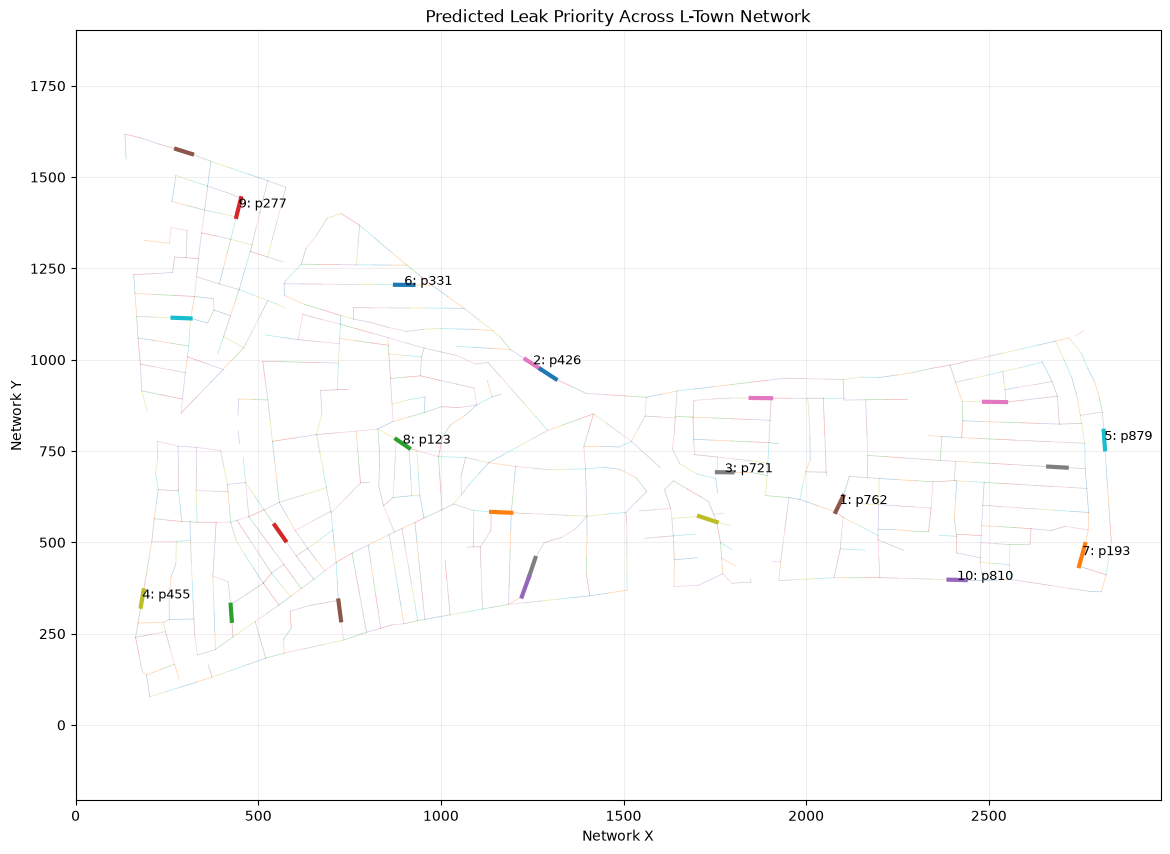

In [91]:
# ==========================================
# NETWORK MAP WITH PREDICTED LEAK LOCATIONS
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# Plot complete network
for _, pipe in all_pipes.iterrows():

    plt.plot(
        [pipe["Start_X"], pipe["End_X"]],
        [pipe["Start_Y"], pipe["End_Y"]],
        linewidth=0.5,
        alpha=0.35
    )

# Plot candidate leak pipes
for _, pipe in final_candidates.iterrows():

    plt.plot(
        [pipe["Start_X"], pipe["End_X"]],
        [pipe["Start_Y"], pipe["End_Y"]],
        linewidth=3
    )

# Label top 10 candidates
for _, pipe in final_candidates.head(10).iterrows():

    plt.text(
        pipe["Mid_X"],
        pipe["Mid_Y"],
        f'{int(pipe["Priority_Rank"])}: {pipe["Leak_Location"]}',
        fontsize=9
    )

plt.title("Predicted Leak Priority Across L-Town Network")
plt.xlabel("Network X")
plt.ylabel("Network Y")

plt.axis("equal")
plt.grid(alpha=0.2)

plt.show()

In [92]:
# ==========================================
# WATER LOSS IMPACT
# ==========================================

impact = final_candidates.copy()

# Convert leakage from L/s to daily water loss
impact["Predicted_Loss_L_per_day"] = (
    impact["Predicted_Current_Leakage"] * 86400
)

# Convert to million litres/day
impact["Predicted_Loss_ML_per_day"] = (
    impact["Predicted_Loss_L_per_day"] / 1_000_000
)

# Keep useful columns
impact = impact[
    [
        "Priority_Rank",
        "Leak_Location",
        "Start_Node",
        "End_Node",
        "Selected_Model",
        "Predicted_Current_Leakage",
        "Predicted_Loss_L_per_day",
        "Predicted_Loss_ML_per_day"
    ]
]

# Sort by leakage
impact = impact.sort_values(
    "Predicted_Current_Leakage",
    ascending=False
).reset_index(drop=True)

# Re-rank after sorting
impact["Priority_Rank"] = impact.index + 1

print("WATER LOSS IMPACT")
print()

print(
    impact.to_string(
        index=False,
        formatters={
            "Predicted_Current_Leakage": "{:.2f}".format,
            "Predicted_Loss_L_per_day": "{:,.0f}".format,
            "Predicted_Loss_ML_per_day": "{:.3f}".format
        }
    )
)

WATER LOSS IMPACT

 Priority_Rank Leak_Location Start_Node End_Node Selected_Model Predicted_Current_Leakage Predicted_Loss_L_per_day Predicted_Loss_ML_per_day
             1          p762       n683     n264    Persistence                     15.53                1,341,792                     1.342
             2          p426       n461     n462    Persistence                     13.25                1,144,800                     1.145
             3          p721       n655     n656    Persistence                     12.95                1,118,880                     1.119
             4          p455       n480     n481    Persistence                     10.96                  946,944                     0.947
             5          p879       n765     n766    Persistence                     10.93                  944,352                     0.944
             6          p331       n398     n399             RF                     10.55                  911,520                     

In [93]:
# ==========================================
# INTERVENTION IMPACT
# ==========================================

RECOVERY_FACTOR = 0.80   # Scenario assumption: 80%

intervention = impact.copy()

# Potential water recovered after intervention
intervention["Recoverable_L_per_day"] = (
    intervention["Predicted_Loss_L_per_day"]
    * RECOVERY_FACTOR
)

intervention["Recoverable_ML_per_day"] = (
    intervention["Recoverable_L_per_day"]
    / 1_000_000
)

intervention["Recovery_Factor"] = RECOVERY_FACTOR

# Keep useful columns
intervention = intervention[
    [
        "Priority_Rank",
        "Leak_Location",
        "Start_Node",
        "End_Node",
        "Selected_Model",
        "Predicted_Current_Leakage",
        "Predicted_Loss_ML_per_day",
        "Recovery_Factor",
        "Recoverable_ML_per_day"
    ]
]

print("INTERVENTION IMPACT")
print("(Recovery factor = 80% scenario assumption)")
print()

print(
    intervention.to_string(
        index=False,
        formatters={
            "Predicted_Current_Leakage": "{:.2f}".format,
            "Predicted_Loss_ML_per_day": "{:.3f}".format,
            "Recovery_Factor": "{:.0%}".format,
            "Recoverable_ML_per_day": "{:.3f}".format
        }
    )
)

INTERVENTION IMPACT
(Recovery factor = 80% scenario assumption)

 Priority_Rank Leak_Location Start_Node End_Node Selected_Model Predicted_Current_Leakage Predicted_Loss_ML_per_day Recovery_Factor Recoverable_ML_per_day
             1          p762       n683     n264    Persistence                     15.53                     1.342             80%                  1.073
             2          p426       n461     n462    Persistence                     13.25                     1.145             80%                  0.916
             3          p721       n655     n656    Persistence                     12.95                     1.119             80%                  0.895
             4          p455       n480     n481    Persistence                     10.96                     0.947             80%                  0.758
             5          p879       n765     n766    Persistence                     10.93                     0.944             80%                  0.755
     

In [95]:
# ==========================================
# REPAIR COST INPUT
# ==========================================

intervention_costs = intervention.copy()

# Repair cost is an external input.
# Leave as NaN until actual/scenario costs are provided.
intervention_costs["Repair_Cost_INR"] = float("nan")

# Cost-effectiveness will be calculated later
intervention_costs["Recoverable_ML_per_INR"] = float("nan")

print(intervention_costs[
    [
        "Priority_Rank",
        "Leak_Location",
        "Start_Node",
        "End_Node",
        "Predicted_Loss_ML_per_day",
        "Recoverable_ML_per_day",
        "Repair_Cost_INR",
        "Recoverable_ML_per_INR"
    ]
].to_string(index=False))

 Priority_Rank Leak_Location Start_Node End_Node  Predicted_Loss_ML_per_day  Recoverable_ML_per_day  Repair_Cost_INR  Recoverable_ML_per_INR
             1          p762       n683     n264                   1.341792                1.073434              NaN                     NaN
             2          p426       n461     n462                   1.144800                0.915840              NaN                     NaN
             3          p721       n655     n656                   1.118880                0.895104              NaN                     NaN
             4          p455       n480     n481                   0.946944                0.757555              NaN                     NaN
             5          p879       n765     n766                   0.944352                0.755482              NaN                     NaN
             6          p331       n398     n399                   0.911520                0.729216              NaN                     NaN
             

In [96]:
# ==========================================
# SCENARIO REPAIR COSTS
# ==========================================

scenario_costs = {
    "p762": 10_00_000,
    "p426": 5_00_000,
    "p721": 10_00_000,
    "p455": 2_00_000,
    "p879": 5_00_000,
    "p331": 5_00_000,
    "p193": 2_00_000,
    "p123": 5_00_000,
    "p277": 2_00_000,
    "p810": 5_00_000,
    "p257": 2_00_000,
    "p710": 5_00_000,
    "p654": 2_00_000,
    "p680": 5_00_000,
    "p280": 2_00_000,
    "p427": 2_00_000
}

intervention_costs["Repair_Cost_INR"] = (
    intervention_costs["Leak_Location"].map(scenario_costs)
)

# Cost-effectiveness
intervention_costs["Recoverable_ML_per_INR"] = (
    intervention_costs["Recoverable_ML_per_day"]
    / intervention_costs["Repair_Cost_INR"]
)

# More readable metric:
# ML recovered per ₹1 lakh spent
intervention_costs["Recoverable_ML_per_1Lakh"] = (
    intervention_costs["Recoverable_ML_per_day"]
    / (intervention_costs["Repair_Cost_INR"] / 1_00_000)
)

# Sort by cost-effectiveness
intervention_costs = intervention_costs.sort_values(
    "Recoverable_ML_per_1Lakh",
    ascending=False
).reset_index(drop=True)

intervention_costs["Intervention_Rank"] = (
    intervention_costs.index + 1
)

print(
    intervention_costs[
        [
            "Intervention_Rank",
            "Leak_Location",
            "Start_Node",
            "End_Node",
            "Predicted_Loss_ML_per_day",
            "Recoverable_ML_per_day",
            "Repair_Cost_INR",
            "Recoverable_ML_per_1Lakh"
        ]
    ].to_string(
        index=False,
        formatters={
            "Predicted_Loss_ML_per_day": "{:.3f}".format,
            "Recoverable_ML_per_day": "{:.3f}".format,
            "Repair_Cost_INR": "₹{:,.0f}".format,
            "Recoverable_ML_per_1Lakh": "{:.3f}".format
        }
    )
)

 Intervention_Rank Leak_Location Start_Node End_Node Predicted_Loss_ML_per_day Recoverable_ML_per_day Repair_Cost_INR Recoverable_ML_per_1Lakh
                 1          p455       n480     n481                     0.947                  0.758        ₹200,000                    0.379
                 2          p193       n326     n327                     0.882                  0.706        ₹200,000                    0.353
                 3          p277       n363      n19                     0.630                  0.504        ₹200,000                    0.252
                 4          p257       n350     n351                     0.585                  0.468        ₹200,000                    0.234
                 5          p654       n609     n610                     0.467                  0.373        ₹200,000                    0.187
                 6          p426       n461     n462                     1.145                  0.916        ₹500,000                    0.183

In [97]:
# ==========================================
# FINAL INTERVENTION DECISION TABLE
# ==========================================

final_decision = intervention_costs.copy()

# Water-loss rank
final_decision["Water_Loss_Rank"] = (
    final_decision["Predicted_Loss_ML_per_day"]
    .rank(
        ascending=False,
        method="min"
    )
)

# Economic rank
final_decision["Cost_Effectiveness_Rank"] = (
    final_decision["Recoverable_ML_per_1Lakh"]
    .rank(
        ascending=False,
        method="min"
    )
)

# Recommendation based on cost-effectiveness
final_decision["Recommendation"] = "Investigate"

final_decision.loc[
    final_decision["Cost_Effectiveness_Rank"] <= 5,
    "Recommendation"
] = "High Priority"

final_decision.loc[
    final_decision["Predicted_Loss_ML_per_day"] >= 1.0,
    "Recommendation"
] = "High Water Loss"

# Display
final_decision = final_decision.sort_values(
    "Water_Loss_Rank"
)

print(
    final_decision[
        [
            "Water_Loss_Rank",
            "Cost_Effectiveness_Rank",
            "Leak_Location",
            "Start_Node",
            "End_Node",
            "Predicted_Loss_ML_per_day",
            "Recoverable_ML_per_day",
            "Repair_Cost_INR",
            "Recoverable_ML_per_1Lakh",
            "Recommendation"
        ]
    ].to_string(
        index=False,
        formatters={
            "Predicted_Loss_ML_per_day": "{:.3f}".format,
            "Recoverable_ML_per_day": "{:.3f}".format,
            "Repair_Cost_INR": lambda x:
                "₹{:,.0f}".format(x) if pd.notna(x) else "N/A",
            "Recoverable_ML_per_1Lakh": lambda x:
                "{:.3f}".format(x) if pd.notna(x) else "N/A"
        }
    )
)

 Water_Loss_Rank  Cost_Effectiveness_Rank Leak_Location Start_Node End_Node Predicted_Loss_ML_per_day Recoverable_ML_per_day Repair_Cost_INR Recoverable_ML_per_1Lakh  Recommendation
             1.0                     12.0          p762       n683     n264                     1.342                  1.073      ₹1,000,000                    0.107 High Water Loss
             2.0                      6.0          p426       n461     n462                     1.145                  0.916        ₹500,000                    0.183 High Water Loss
             3.0                     14.0          p721       n655     n656                     1.119                  0.895      ₹1,000,000                    0.090 High Water Loss
             4.0                      1.0          p455       n480     n481                     0.947                  0.758        ₹200,000                    0.379   High Priority
             5.0                      9.0          p879       n765     n766               

In [99]:
# ==========================================
# CLEAN FINAL RECOMMENDATIONS
# ==========================================

final_decision = intervention_costs.copy()

# Start with no current predicted loss
final_decision["Recommendation"] = "No current predicted loss"

# Cost-efficient candidates
cost_efficient = (
    final_decision["Cost_Effectiveness_Rank"] <= 5
)

# High water-loss candidates
critical_loss = (
    final_decision["Predicted_Loss_ML_per_day"] >= 1.0
)

high_loss = (
    (final_decision["Predicted_Loss_ML_per_day"] >= 0.75)
    &
    (final_decision["Predicted_Loss_ML_per_day"] < 1.0)
)

# Apply labels
final_decision.loc[
    final_decision["Predicted_Loss_ML_per_day"] > 0,
    "Recommendation"
] = "Investigate"

final_decision.loc[
    high_loss,
    "Recommendation"
] = "High Water Loss"

final_decision.loc[
    critical_loss,
    "Recommendation"
] = "Critical Water Loss"

# Cost efficiency gets its own explicit label,
# but don't overwrite critical water-loss information.
final_decision.loc[
    cost_efficient &
    (final_decision["Predicted_Loss_ML_per_day"] < 1.0),
    "Recommendation"
] = "Cost Efficient"

print(
    final_decision[
        [
            "Water_Loss_Rank",
            "Cost_Effectiveness_Rank",
            "Leak_Location",
            "Start_Node",
            "End_Node",
            "Predicted_Loss_ML_per_day",
            "Recoverable_ML_per_day",
            "Repair_Cost_INR",
            "Recoverable_ML_per_1Lakh",
            "Recommendation"
        ]
    ].to_string(
        index=False,
        formatters={
            "Predicted_Loss_ML_per_day": "{:.3f}".format,
            "Recoverable_ML_per_day": "{:.3f}".format,
            "Repair_Cost_INR": lambda x:
                "₹{:,.0f}".format(x)
                if pd.notna(x) else "N/A",
            "Recoverable_ML_per_1Lakh": lambda x:
                "{:.3f}".format(x)
                if pd.notna(x) else "N/A"
        }
    )
)

KeyError: 'Cost_Effectiveness_Rank'

In [100]:
# ==========================================
# CLEAN FINAL RECOMMENDATIONS
# ==========================================

final_decision = intervention_costs.copy()

# Create ranks again
final_decision["Water_Loss_Rank"] = (
    final_decision["Predicted_Loss_ML_per_day"]
    .rank(ascending=False, method="min")
)

final_decision["Cost_Effectiveness_Rank"] = (
    final_decision["Recoverable_ML_per_1Lakh"]
    .rank(ascending=False, method="min")
)

# Default
final_decision["Recommendation"] = "No current predicted loss"

# Conditions
critical_loss = (
    final_decision["Predicted_Loss_ML_per_day"] >= 1.0
)

high_loss = (
    (final_decision["Predicted_Loss_ML_per_day"] >= 0.75)
    &
    (final_decision["Predicted_Loss_ML_per_day"] < 1.0)
)

cost_efficient = (
    final_decision["Cost_Effectiveness_Rank"] <= 5
)

# Assign recommendations
final_decision.loc[
    final_decision["Predicted_Loss_ML_per_day"] > 0,
    "Recommendation"
] = "Investigate"

final_decision.loc[
    high_loss,
    "Recommendation"
] = "High Water Loss"

final_decision.loc[
    critical_loss,
    "Recommendation"
] = "Critical Water Loss"

# Cost efficient only where not already critical/high loss
final_decision.loc[
    cost_efficient &
    (final_decision["Predicted_Loss_ML_per_day"] < 0.75),
    "Recommendation"
] = "Cost Efficient"

# Sort by water loss
final_decision = final_decision.sort_values(
    "Water_Loss_Rank"
).reset_index(drop=True)

print(
    final_decision[
        [
            "Water_Loss_Rank",
            "Cost_Effectiveness_Rank",
            "Leak_Location",
            "Start_Node",
            "End_Node",
            "Predicted_Loss_ML_per_day",
            "Recoverable_ML_per_day",
            "Repair_Cost_INR",
            "Recoverable_ML_per_1Lakh",
            "Recommendation"
        ]
    ].to_string(
        index=False,
        formatters={
            "Predicted_Loss_ML_per_day": "{:.3f}".format,
            "Recoverable_ML_per_day": "{:.3f}".format,
            "Repair_Cost_INR": lambda x:
                "₹{:,.0f}".format(x)
                if pd.notna(x) else "N/A",
            "Recoverable_ML_per_1Lakh": lambda x:
                "{:.3f}".format(x)
                if pd.notna(x) else "N/A"
        }
    )
)

 Water_Loss_Rank  Cost_Effectiveness_Rank Leak_Location Start_Node End_Node Predicted_Loss_ML_per_day Recoverable_ML_per_day Repair_Cost_INR Recoverable_ML_per_1Lakh            Recommendation
             1.0                     12.0          p762       n683     n264                     1.342                  1.073      ₹1,000,000                    0.107       Critical Water Loss
             2.0                      6.0          p426       n461     n462                     1.145                  0.916        ₹500,000                    0.183       Critical Water Loss
             3.0                     14.0          p721       n655     n656                     1.119                  0.895      ₹1,000,000                    0.090       Critical Water Loss
             4.0                      1.0          p455       n480     n481                     0.947                  0.758        ₹200,000                    0.379           High Water Loss
             5.0                      9.

In [101]:
# ==========================================
# BUILD WATER NETWORK GRAPH
# ==========================================

import networkx as nx

G = nx.Graph()

# Add every pipe as an edge
for _, pipe in all_pipes.iterrows():
    G.add_edge(
        pipe["Start_Node"],
        pipe["End_Node"],
        pipe_id=pipe["Pipe"]
    )

print("Network graph created")
print("Nodes:", G.number_of_nodes())
print("Pipes/edges:", G.number_of_edges())

Network graph created
Nodes: 785
Pipes/edges: 905


In [102]:
# ==========================================
# NETWORK DISTANCE BETWEEN CANDIDATE PIPES
# ==========================================

active_candidates = final_decision[
    final_decision["Predicted_Loss_ML_per_day"] > 0
].copy()

candidate_pipes = active_candidates["Leak_Location"].tolist()

network_distances = []

for i, pipe_a in enumerate(candidate_pipes):
    
    row_a = all_pipes[all_pipes["Pipe"] == pipe_a].iloc[0]
    
    for pipe_b in candidate_pipes[i + 1:]:
        
        row_b = all_pipes[all_pipes["Pipe"] == pipe_b].iloc[0]
        
        # Four possible endpoint combinations
        distances = []
        
        for node_a in [row_a["Start_Node"], row_a["End_Node"]]:
            for node_b in [row_b["Start_Node"], row_b["End_Node"]]:
                
                try:
                    d = nx.shortest_path_length(
                        G,
                        node_a,
                        node_b
                    )
                    distances.append(d)
                except nx.NetworkXNoPath:
                    pass
        
        if distances:
            shortest_distance = min(distances)
            
            network_distances.append([
                pipe_a,
                pipe_b,
                shortest_distance
            ])

network_distances = pd.DataFrame(
    network_distances,
    columns=[
        "Pipe_A",
        "Pipe_B",
        "Network_Distance"
    ]
)

print("Candidate pipe network distances:")
print(
    network_distances.sort_values(
        "Network_Distance"
    ).head(30).to_string(index=False)
)

Candidate pipe network distances:
Pipe_A Pipe_B  Network_Distance
  p426   p427                 0
  p277   p257                 4
  p721   p710                 6
  p762   p721                 7
  p277   p280                 7
  p426   p331                 8
  p257   p280                 8
  p762   p710                 9
  p331   p427                 9
  p879   p193                 9
  p762   p810                10
  p193   p810                11
  p710   p427                13
  p721   p427                13
  p426   p710                14
  p426   p721                14
  p879   p810                16
  p123   p654                16
  p721   p810                17
  p810   p710                19
  p762   p879                19
  p654   p427                19
  p762   p193                19
  p426   p654                20
  p710   p654                21
  p721   p654                21
  p762   p427                21
  p331   p123                22
  p123   p427                22
  p455

In [103]:
# ==========================================
# CLUSTER CANDIDATE PIPES BY NETWORK DISTANCE
# ==========================================

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# All active candidates
candidate_pipes = active_candidates["Leak_Location"].tolist()

# Create distance matrix
distance_matrix = pd.DataFrame(
    0,
    index=candidate_pipes,
    columns=candidate_pipes,
    dtype=float
)

for _, row in network_distances.iterrows():
    distance_matrix.loc[row["Pipe_A"], row["Pipe_B"]] = row["Network_Distance"]
    distance_matrix.loc[row["Pipe_B"], row["Pipe_A"]] = row["Network_Distance"]

# Convert to condensed distance format
condensed_distances = squareform(
    distance_matrix.values
)

# Hierarchical clustering
Z = linkage(
    condensed_distances,
    method="average"
)

# Create 4 network regions for initial inspection
region_labels = fcluster(
    Z,
    t=4,
    criterion="maxclust"
)

candidate_regions = pd.DataFrame({
    "Leak_Location": candidate_pipes,
    "Network_Region": region_labels
})

# Add impact information
candidate_regions = candidate_regions.merge(
    active_candidates[
        [
            "Leak_Location",
            "Predicted_Loss_ML_per_day",
            "Recoverable_ML_per_day"
        ]
    ],
    on="Leak_Location"
)

# Sort by region and impact
candidate_regions = candidate_regions.sort_values(
    ["Network_Region", "Predicted_Loss_ML_per_day"],
    ascending=[True, False]
)

print("NETWORK REGIONS")
print()

print(
    candidate_regions.to_string(
        index=False,
        formatters={
            "Predicted_Loss_ML_per_day": "{:.3f}".format,
            "Recoverable_ML_per_day": "{:.3f}".format
        }
    )
)

NETWORK REGIONS

Leak_Location  Network_Region Predicted_Loss_ML_per_day Recoverable_ML_per_day
         p879               1                     0.944                  0.755
         p193               1                     0.882                  0.706
         p810               1                     0.586                  0.469
         p762               2                     1.342                  1.073
         p426               2                     1.145                  0.916
         p721               2                     1.119                  0.895
         p331               2                     0.912                  0.729
         p277               2                     0.630                  0.504
         p257               2                     0.585                  0.468
         p710               2                     0.472                  0.377
         p680               2                     0.463                  0.371
         p427               2      

In [104]:
# ==========================================
# REGION-LEVEL IMPACT SUMMARY
# ==========================================

region_summary = (
    candidate_regions
    .groupby("Network_Region")
    .agg(
        Candidate_Pipes=("Leak_Location", "count"),
        Total_Estimated_Loss_ML_per_day=(
            "Predicted_Loss_ML_per_day", "sum"
        ),
        Potential_Recovery_ML_per_day=(
            "Recoverable_ML_per_day", "sum"
        ),
        Highest_Loss_Pipe=(
            "Leak_Location",
            lambda x: x.iloc[
                candidate_regions.loc[x.index]
                ["Predicted_Loss_ML_per_day"]
                .argmax()
            ]
        )
    )
    .reset_index()
)

region_summary = region_summary.sort_values(
    "Total_Estimated_Loss_ML_per_day",
    ascending=False
).reset_index(drop=True)

region_summary["Region_Priority"] = (
    region_summary.index + 1
)

print("REGION-LEVEL IMPACT")
print()

print(
    region_summary[
        [
            "Region_Priority",
            "Network_Region",
            "Candidate_Pipes",
            "Total_Estimated_Loss_ML_per_day",
            "Potential_Recovery_ML_per_day",
            "Highest_Loss_Pipe"
        ]
    ].to_string(
        index=False,
        formatters={
            "Total_Estimated_Loss_ML_per_day": "{:.3f}".format,
            "Potential_Recovery_ML_per_day": "{:.3f}".format
        }
    )
)

REGION-LEVEL IMPACT

 Region_Priority  Network_Region  Candidate_Pipes Total_Estimated_Loss_ML_per_day Potential_Recovery_ML_per_day Highest_Loss_Pipe
               1               2                9                           7.096                         5.677              p762
               2               1                3                           2.413                         1.930              p879
               3               3                3                           2.179                         1.743              p455
               4               4                1                           0.467                         0.373              p654


In [105]:
# ==========================================
# FINAL REGION + PIPE PRIORITY TABLE
# ==========================================

final_priority = candidate_regions.merge(
    intervention_costs[
        [
            "Leak_Location",
            "Repair_Cost_INR",
            "Recoverable_ML_per_1Lakh",
            "Recommendation"
        ]
    ],
    on="Leak_Location",
    how="left"
)

final_priority = final_priority.merge(
    all_pipes[
        [
            "Pipe",
            "Start_Node",
            "End_Node"
        ]
    ],
    left_on="Leak_Location",
    right_on="Pipe",
    how="left"
)

final_priority = final_priority.sort_values(
    [
        "Network_Region",
        "Predicted_Loss_ML_per_day"
    ],
    ascending=[True, False]
).reset_index(drop=True)

final_priority["Pipe_Priority"] = (
    final_priority.index + 1
)

final_priority = final_priority[
    [
        "Network_Region",
        "Pipe_Priority",
        "Leak_Location",
        "Start_Node",
        "End_Node",
        "Predicted_Loss_ML_per_day",
        "Recoverable_ML_per_day",
        "Repair_Cost_INR",
        "Recoverable_ML_per_1Lakh",
        "Recommendation"
    ]
]

print(
    final_priority.to_string(
        index=False,
        formatters={
            "Predicted_Loss_ML_per_day": "{:.3f}".format,
            "Recoverable_ML_per_day": "{:.3f}".format,
            "Recoverable_ML_per_1Lakh": "{:.3f}".format
        }
    )
)

KeyError: "['Recommendation'] not in index"

In [106]:
# ==========================================
# FINAL REGION + PIPE PRIORITY TABLE
# ==========================================

final_priority = candidate_regions.merge(
    final_decision[
        [
            "Leak_Location",
            "Repair_Cost_INR",
            "Recoverable_ML_per_1Lakh",
            "Recommendation"
        ]
    ],
    on="Leak_Location",
    how="left"
)

final_priority = final_priority.merge(
    all_pipes[
        [
            "Pipe",
            "Start_Node",
            "End_Node"
        ]
    ],
    left_on="Leak_Location",
    right_on="Pipe",
    how="left"
)

final_priority = final_priority.sort_values(
    [
        "Network_Region",
        "Predicted_Loss_ML_per_day"
    ],
    ascending=[True, False]
).reset_index(drop=True)

final_priority["Pipe_Priority"] = (
    final_priority.index + 1
)

final_priority = final_priority[
    [
        "Network_Region",
        "Pipe_Priority",
        "Leak_Location",
        "Start_Node",
        "End_Node",
        "Predicted_Loss_ML_per_day",
        "Recoverable_ML_per_day",
        "Repair_Cost_INR",
        "Recoverable_ML_per_1Lakh",
        "Recommendation"
    ]
]

print(
    final_priority.to_string(
        index=False,
        formatters={
            "Predicted_Loss_ML_per_day": "{:.3f}".format,
            "Recoverable_ML_per_day": "{:.3f}".format,
            "Recoverable_ML_per_1Lakh": "{:.3f}".format
        }
    )
)

 Network_Region  Pipe_Priority Leak_Location Start_Node End_Node Predicted_Loss_ML_per_day Recoverable_ML_per_day  Repair_Cost_INR Recoverable_ML_per_1Lakh      Recommendation
              1              1          p879       n765     n766                     0.944                  0.755         500000.0                    0.151     High Water Loss
              1              2          p193       n326     n327                     0.882                  0.706         200000.0                    0.353     High Water Loss
              1              3          p810       n716     n717                     0.586                  0.469         500000.0                    0.094         Investigate
              2              4          p762       n683     n264                     1.342                  1.073        1000000.0                    0.107 Critical Water Loss
              2              5          p426       n461     n462                     1.145                  0.916       

In [107]:
# ==========================================
# FINAL PRIORITY RANKING
# ==========================================

# Region priority from total estimated loss
region_priority_map = (
    region_summary
    .set_index("Network_Region")["Region_Priority"]
    .to_dict()
)

final_priority["Region_Priority"] = (
    final_priority["Network_Region"]
    .map(region_priority_map)
)

# Rank pipes within each region by estimated loss
final_priority["Pipe_Priority_Within_Region"] = (
    final_priority
    .groupby("Network_Region")["Predicted_Loss_ML_per_day"]
    .rank(
        ascending=False,
        method="first"
    )
    .astype(int)
)

final_priority = final_priority.sort_values(
    [
        "Region_Priority",
        "Pipe_Priority_Within_Region"
    ]
).reset_index(drop=True)

final_priority = final_priority[
    [
        "Region_Priority",
        "Network_Region",
        "Pipe_Priority_Within_Region",
        "Leak_Location",
        "Start_Node",
        "End_Node",
        "Predicted_Loss_ML_per_day",
        "Recoverable_ML_per_day",
        "Repair_Cost_INR",
        "Recoverable_ML_per_1Lakh",
        "Recommendation"
    ]
]

print(
    final_priority.to_string(
        index=False,
        formatters={
            "Predicted_Loss_ML_per_day": "{:.3f}".format,
            "Recoverable_ML_per_day": "{:.3f}".format,
            "Recoverable_ML_per_1Lakh": "{:.3f}".format
        }
    )
)

 Region_Priority  Network_Region  Pipe_Priority_Within_Region Leak_Location Start_Node End_Node Predicted_Loss_ML_per_day Recoverable_ML_per_day  Repair_Cost_INR Recoverable_ML_per_1Lakh      Recommendation
               1               2                            1          p762       n683     n264                     1.342                  1.073        1000000.0                    0.107 Critical Water Loss
               1               2                            2          p426       n461     n462                     1.145                  0.916         500000.0                    0.183 Critical Water Loss
               1               2                            3          p721       n655     n656                     1.119                  0.895        1000000.0                    0.090 Critical Water Loss
               1               2                            4          p331       n398     n399                     0.912                  0.729         500000.0           

In [109]:
# ==========================================
# FINAL BACKEND OUTPUT CHECK
# ==========================================

print("FINAL BACKEND OUTPUT")
print("=" * 60)

print("\n1. FINAL INTERVENTION PRIORITIES")
print("Shape:", final_priority.shape)
print("Columns:")
print(final_priority.columns.tolist())

print("\nTop candidates:")
print(
    final_priority[
        [
            "Region_Priority",
            "Network_Region",
            "Pipe_Priority_Within_Region",
            "Leak_Location",
            "Predicted_Loss_ML_per_day",
            "Recoverable_ML_per_day",
            "Repair_Cost_INR",
            "Recommendation"
        ]
    ].head(10).to_string(index=False)
)

print("\n2. NETWORK TOPOLOGY")
print("Shape:", all_pipes.shape)
print("Columns:")
print(all_pipes.columns.tolist())

print("\n3. CANDIDATE PIPE LOCATIONS")
print("Shape:", candidate_map.shape())
print("Columns:")
print(candidate_map.columns.tolist())

FINAL BACKEND OUTPUT

1. FINAL INTERVENTION PRIORITIES
Shape: (16, 11)
Columns:
['Region_Priority', 'Network_Region', 'Pipe_Priority_Within_Region', 'Leak_Location', 'Start_Node', 'End_Node', 'Predicted_Loss_ML_per_day', 'Recoverable_ML_per_day', 'Repair_Cost_INR', 'Recoverable_ML_per_1Lakh', 'Recommendation']

Top candidates:
 Region_Priority  Network_Region  Pipe_Priority_Within_Region Leak_Location  Predicted_Loss_ML_per_day  Recoverable_ML_per_day  Repair_Cost_INR      Recommendation
               1               2                            1          p762                   1.341792                1.073434        1000000.0 Critical Water Loss
               1               2                            2          p426                   1.144800                0.915840         500000.0 Critical Water Loss
               1               2                            3          p721                   1.118880                0.895104        1000000.0 Critical Water Loss
               

NameError: name 'candidate_map' is not defined

In [110]:
# ==========================================
# CREATE + CHECK FINAL BACKEND OUTPUTS
# ==========================================

# 1. Create candidate map data
candidate_map = final_priority.merge(
    all_pipes[
        [
            "Pipe",
            "Start_X",
            "Start_Y",
            "End_X",
            "End_Y"
        ]
    ],
    left_on="Leak_Location",
    right_on="Pipe",
    how="left"
)

print("FINAL BACKEND OUTPUT")
print("=" * 60)

# ------------------------------------------
# 1. FINAL INTERVENTION PRIORITIES
# ------------------------------------------

print("\n1. FINAL INTERVENTION PRIORITIES")
print("Shape:", final_priority.shape)
print("Columns:")
print(final_priority.columns.tolist())

print("\nTop candidates:")
print(
    final_priority[
        [
            "Region_Priority",
            "Network_Region",
            "Pipe_Priority_Within_Region",
            "Leak_Location",
            "Predicted_Loss_ML_per_day",
            "Recoverable_ML_per_day",
            "Repair_Cost_INR",
            "Recommendation"
        ]
    ].head(10).to_string(index=False)
)

# ------------------------------------------
# 2. COMPLETE NETWORK TOPOLOGY
# ------------------------------------------

print("\n2. NETWORK TOPOLOGY")
print("Shape:", all_pipes.shape)
print("Columns:")
print(all_pipes.columns.tolist())

# ------------------------------------------
# 3. CANDIDATE PIPE LOCATIONS
# ------------------------------------------

print("\n3. CANDIDATE PIPE LOCATIONS")
print("Shape:", candidate_map.shape)
print("Columns:")
print(candidate_map.columns.tolist())

FINAL BACKEND OUTPUT

1. FINAL INTERVENTION PRIORITIES
Shape: (16, 11)
Columns:
['Region_Priority', 'Network_Region', 'Pipe_Priority_Within_Region', 'Leak_Location', 'Start_Node', 'End_Node', 'Predicted_Loss_ML_per_day', 'Recoverable_ML_per_day', 'Repair_Cost_INR', 'Recoverable_ML_per_1Lakh', 'Recommendation']

Top candidates:
 Region_Priority  Network_Region  Pipe_Priority_Within_Region Leak_Location  Predicted_Loss_ML_per_day  Recoverable_ML_per_day  Repair_Cost_INR      Recommendation
               1               2                            1          p762                   1.341792                1.073434        1000000.0 Critical Water Loss
               1               2                            2          p426                   1.144800                0.915840         500000.0 Critical Water Loss
               1               2                            3          p721                   1.118880                0.895104        1000000.0 Critical Water Loss
               

In [111]:
# ==========================================
# EXPORT FINAL BACKEND FILES
# ==========================================

final_priority.to_csv(
    "../data/final_intervention_priorities.csv",
    index=False
)

all_pipes.to_csv(
    "../data/network_topology.csv",
    index=False
)

candidate_map.to_csv(
    "../data/candidate_pipe_locations.csv",
    index=False
)

print("FINAL BACKEND FILES EXPORTED")
print("=" * 50)
print("✓ final_intervention_priorities.csv")
print("✓ network_topology.csv")
print("✓ candidate_pipe_locations.csv")

FINAL BACKEND FILES EXPORTED
✓ final_intervention_priorities.csv
✓ network_topology.csv
✓ candidate_pipe_locations.csv


In [112]:
import json

# Final intervention priorities
final_priority.to_json(
    "../data/final_intervention_priorities.json",
    orient="records",
    indent=2
)

# Full network topology
all_pipes.to_json(
    "../data/network_topology.json",
    orient="records",
    indent=2
)

# Candidate pipes + coordinates
candidate_map.to_json(
    "../data/candidate_pipe_locations.json",
    orient="records",
    indent=2
)

print("JSON files created successfully.")

JSON files created successfully.


In [113]:
final_priority

,Region_Priority,Network_Region,Pipe_Priority_Within_Region,Leak_Location,Start_Node,End_Node,Predicted_Loss_ML_per_day,Recoverable_ML_per_day,Repair_Cost_INR,Recoverable_ML_per_1Lakh,Recommendation
0,1,2,1,p762,n683,n264,1.341792,1.073434,1000000.0,0.107343,Critical Water Loss
1,1,2,2,p426,n461,n462,1.144800,0.915840,500000.0,0.183168,Critical Water Loss
2,1,2,3,p721,n655,n656,1.118880,0.895104,1000000.0,0.089510,Critical Water Loss
3,1,2,4,p331,n398,n399,0.911520,0.729216,500000.0,0.145843,High Water Loss
4,1,2,5,p277,n363,n19,0.629828,0.503863,200000.0,0.251931,Cost Efficient
5,1,2,6,p257,n350,n351,0.584928,0.467942,200000.0,0.233971,Cost Efficient
6,1,2,7,p710,n648,n228,0.471740,0.377392,500000.0,0.075478,Investigate
7,1,2,8,p680,n626,n233,0.463136,0.370509,500000.0,0.074102,Investigate
8,1,2,9,p427,n462,n340,0.429761,0.343809,200000.0,0.171904,Investigate
9,2,1,1,p879,n765,n766,0.944352,0.755482,500000.0,0.151096,High Water Loss


In [2]:
import pandas as pd

final_priority = pd.read_csv(
    "../data/final_intervention_priorities.csv"
)

final_priority.head()

,Region_Priority,Network_Region,Pipe_Priority_Within_Region,Leak_Location,Start_Node,End_Node,Predicted_Loss_ML_per_day,Recoverable_ML_per_day,Repair_Cost_INR,Recoverable_ML_per_1Lakh,Recommendation
0,1,2,1,p762,n683,n264,1.341792,1.073434,1000000.0,0.107343,Critical Water Loss
1,1,2,2,p426,n461,n462,1.144800,0.915840,500000.0,0.183168,Critical Water Loss
2,1,2,3,p721,n655,n656,1.118880,0.895104,1000000.0,0.089510,Critical Water Loss
3,1,2,4,p331,n398,n399,0.911520,0.729216,500000.0,0.145843,High Water Loss
4,1,2,5,p277,n363,n19,0.629828,0.503863,200000.0,0.251931,Cost Efficient


In [3]:
candidate_nodes = sorted(
    set(final_priority["Start_Node"]) |
    set(final_priority["End_Node"])
)

candidate_nodes

['n155',
 'n159',
 'n19',
 'n228',
 'n23',
 'n233',
 'n264',
 'n326',
 'n327',
 'n340',
 'n350',
 'n351',
 'n363',
 'n365',
 'n398',
 'n399',
 'n461',
 'n462',
 'n480',
 'n481',
 'n609',
 'n610',
 'n626',
 'n648',
 'n655',
 'n656',
 'n683',
 'n716',
 'n717',
 'n765',
 'n766']

In [4]:
demo_locations = {
    "n155": ("Bengaluru", "Akshayanagar"),
    "n159": ("Bengaluru", "Akshayanagar"),
    "n19": ("Bengaluru", "JP Nagar"),
    "n228": ("Bengaluru", "Bannerghatta Road"),
    "n23": ("Bengaluru", "Arekere"),
    "n233": ("Bengaluru", "Arekere"),
    "n264": ("Bengaluru", "HSR Layout"),
    "n326": ("Bengaluru", "Electronic City"),
    "n327": ("Bengaluru", "Electronic City"),
    "n340": ("Bengaluru", "Bommanahalli"),
    "n350": ("Bengaluru", "Hulimavu"),
    "n351": ("Bengaluru", "Hulimavu"),
    "n363": ("Bengaluru", "JP Nagar"),
    "n365": ("Bengaluru", "Arekere"),
    "n398": ("Bengaluru", "Bannerghatta Road"),
    "n399": ("Bengaluru", "Bannerghatta Road"),
    "n461": ("Bengaluru", "BTM Layout"),
    "n462": ("Bengaluru", "BTM Layout"),
    "n480": ("Bengaluru", "Jayanagar"),
    "n481": ("Bengaluru", "Jayanagar"),
    "n609": ("Bengaluru", "Begur"),
    "n610": ("Bengaluru", "Begur"),
    "n626": ("Bengaluru", "HSR Layout"),
    "n648": ("Bengaluru", "Bannerghatta Road"),
    "n655": ("Bengaluru", "JP Nagar"),
    "n656": ("Bengaluru", "JP Nagar"),
    "n683": ("Bengaluru", "Akshayanagar"),
    "n716": ("Bengaluru", "Electronic City"),
    "n717": ("Bengaluru", "Electronic City"),
    "n765": ("Bengaluru", "Sarjapur Road"),
    "n766": ("Bengaluru", "Sarjapur Road")
}

In [5]:
node_directory = pd.DataFrame(
    [
        {
            "Node_ID": node,
            "City": city,
            "Area": area,
            "Location_Type": "Demo / Simulated"
        }
        for node, (city, area) in demo_locations.items()
    ]
)

node_directory.to_json(
    "../data/node_directory.json",
    orient="records",
    indent=2
)

node_directory

,Node_ID,City,Area,Location_Type
0,n155,Bengaluru,Akshayanagar,Demo / Simulated
1,n159,Bengaluru,Akshayanagar,Demo / Simulated
2,n19,Bengaluru,JP Nagar,Demo / Simulated
3,n228,Bengaluru,Bannerghatta Road,Demo / Simulated
4,n23,Bengaluru,Arekere,Demo / Simulated
5,n233,Bengaluru,Arekere,Demo / Simulated
6,n264,Bengaluru,HSR Layout,Demo / Simulated
7,n326,Bengaluru,Electronic City,Demo / Simulated
8,n327,Bengaluru,Electronic City,Demo / Simulated
9,n340,Bengaluru,Bommanahalli,Demo / Simulated


In [6]:
import pandas as pd
import json

final_priority = pd.read_csv("../data/final_intervention_priorities.csv")
all_pipes = pd.read_csv("../data/network_topology.csv")
node_directory = pd.read_json("../data/node_directory.json")

print("Final priorities:", final_priority.shape)
print("Network pipes:", all_pipes.shape)
print("Node directory:", node_directory.shape)

Final priorities: (16, 11)
Network pipes: (905, 7)
Node directory: (31, 4)


In [7]:
node_pipes = []

for _, node in node_directory.iterrows():
    node_id = node["Node_ID"]

    connected = all_pipes[
        (all_pipes["Start_Node"] == node_id) |
        (all_pipes["End_Node"] == node_id)
    ]

    for _, pipe in connected.iterrows():
        node_pipes.append({
            "Node_ID": node_id,
            "City": node["City"],
            "Area": node["Area"],
            "Location_Type": node["Location_Type"],
            "Pipe": pipe["Pipe"],
            "Start_Node": pipe["Start_Node"],
            "End_Node": pipe["End_Node"]
        })

node_pipes = pd.DataFrame(node_pipes)

node_pipes.head(10)

,Node_ID,City,Area,Location_Type,Pipe,Start_Node,End_Node
0,n155,Bengaluru,Akshayanagar,Demo / Simulated,p119,n144,n155
1,n155,Bengaluru,Akshayanagar,Demo / Simulated,p123,n155,n159
2,n155,Bengaluru,Akshayanagar,Demo / Simulated,p557,n155,n542
3,n159,Bengaluru,Akshayanagar,Demo / Simulated,p84,n162,n159
4,n159,Bengaluru,Akshayanagar,Demo / Simulated,p123,n155,n159
5,n159,Bengaluru,Akshayanagar,Demo / Simulated,p570,n159,n551
6,n19,Bengaluru,JP Nagar,Demo / Simulated,p250,n19,n345
7,n19,Bengaluru,JP Nagar,Demo / Simulated,p277,n363,n19
8,n19,Bengaluru,JP Nagar,Demo / Simulated,p289,n19,n371
9,n228,Bengaluru,Bannerghatta Road,Demo / Simulated,p156,n228,n232


In [8]:
# Add intervention information to the connected pipes
node_pipes = node_pipes.merge(
    final_priority[
        [
            "Leak_Location",
            "Network_Region",
            "Predicted_Loss_ML_per_day",
            "Recoverable_ML_per_day",
            "Repair_Cost_INR",
            "Recoverable_ML_per_1Lakh",
            "Recommendation"
        ]
    ],
    left_on="Pipe",
    right_on="Leak_Location",
    how="left"
)

# Mark whether this pipe is one of our intervention candidates
node_pipes["Is_Candidate"] = node_pipes["Leak_Location"].notna()

node_pipes.head(10)

,Node_ID,City,Area,Location_Type,Pipe,Start_Node,End_Node,Leak_Location,Network_Region,Predicted_Loss_ML_per_day,Recoverable_ML_per_day,Repair_Cost_INR,Recoverable_ML_per_1Lakh,Recommendation,Is_Candidate
0,n155,Bengaluru,Akshayanagar,Demo / Simulated,p119,n144,n155,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,n155,Bengaluru,Akshayanagar,Demo / Simulated,p123,n155,n159,p123,3.0,0.781920,0.625536,500000.0,0.125107,High Water Loss,True
2,n155,Bengaluru,Akshayanagar,Demo / Simulated,p557,n155,n542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,n159,Bengaluru,Akshayanagar,Demo / Simulated,p84,n162,n159,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,n159,Bengaluru,Akshayanagar,Demo / Simulated,p123,n155,n159,p123,3.0,0.781920,0.625536,500000.0,0.125107,High Water Loss,True
5,n159,Bengaluru,Akshayanagar,Demo / Simulated,p570,n159,n551,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
6,n19,Bengaluru,JP Nagar,Demo / Simulated,p250,n19,n345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
7,n19,Bengaluru,JP Nagar,Demo / Simulated,p277,n363,n19,p277,2.0,0.629828,0.503863,200000.0,0.251931,Cost Efficient,True
8,n19,Bengaluru,JP Nagar,Demo / Simulated,p289,n19,n371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
9,n228,Bengaluru,Bannerghatta Road,Demo / Simulated,p156,n228,n232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [9]:
# Replace empty values with None so they become null in JSON
node_pipes = node_pipes.where(pd.notna(node_pipes), None)

# Convert each node into a searchable record
node_search_data = []

for node_id, group in node_pipes.groupby("Node_ID"):
    first = group.iloc[0]

    pipes = []

    for _, row in group.iterrows():
        pipe = {
            "Pipe": row["Pipe"],
            "Start_Node": row["Start_Node"],
            "End_Node": row["End_Node"],
            "Is_Candidate": row["Is_Candidate"]
        }

        if row["Is_Candidate"]:
            pipe.update({
                "Network_Region": row["Network_Region"],
                "Predicted_Loss_ML_per_day": row["Predicted_Loss_ML_per_day"],
                "Recoverable_ML_per_day": row["Recoverable_ML_per_day"],
                "Repair_Cost_INR": row["Repair_Cost_INR"],
                "Recoverable_ML_per_1Lakh": row["Recoverable_ML_per_1Lakh"],
                "Recommendation": row["Recommendation"]
            })

        pipes.append(pipe)

    node_search_data.append({
        "Node_ID": node_id,
        "City": first["City"],
        "Area": first["Area"],
        "Location_Type": first["Location_Type"],
        "Connected_Pipes": pipes
    })

# Save it
with open("../data/node_search_data.json", "w") as f:
    json.dump(node_search_data, f, indent=2)

print("Created node_search_data.json")
print("Nodes:", len(node_search_data))

Created node_search_data.json
Nodes: 31


In [10]:
import json

with open("../data/node_search_data.json", "r") as f:
    data = json.load(f)

print("Number of nodes:", len(data))

# Show the first node
print(json.dumps(data[0], indent=2))

Number of nodes: 31
{
  "Node_ID": "n155",
  "City": "Bengaluru",
  "Area": "Akshayanagar",
  "Location_Type": "Demo / Simulated",
  "Connected_Pipes": [
    {
      "Pipe": "p119",
      "Start_Node": "n144",
      "End_Node": "n155",
      "Is_Candidate": false
    },
    {
      "Pipe": "p123",
      "Start_Node": "n155",
      "End_Node": "n159",
      "Is_Candidate": true,
      "Network_Region": 3.0,
      "Predicted_Loss_ML_per_day": 0.7819200000000002,
      "Recoverable_ML_per_day": 0.6255360000000001,
      "Repair_Cost_INR": 500000.0,
      "Recoverable_ML_per_1Lakh": 0.1251072,
      "Recommendation": "High Water Loss"
    },
    {
      "Pipe": "p557",
      "Start_Node": "n155",
      "End_Node": "n542",
      "Is_Candidate": false
    }
  ]
}


In [11]:
results = [
    node for node in data
    if "akshayanagar" in node["Area"].lower()
]

for node in results:
    print(node["Node_ID"], "-", node["Area"])
    
    for pipe in node["Connected_Pipes"]:
        if pipe["Is_Candidate"]:
            print(
                "  Candidate:",
                pipe["Pipe"],
                "| Loss:",
                pipe["Predicted_Loss_ML_per_day"],
                "ML/day"
            )

n155 - Akshayanagar
  Candidate: p123 | Loss: 0.7819200000000002 ML/day
n159 - Akshayanagar
  Candidate: p123 | Loss: 0.7819200000000002 ML/day
n683 - Akshayanagar
  Candidate: p762 | Loss: 1.341792 ML/day
